In [ ]:
# %pip install scikit-image
# %pip install seaborn
%pip install scikit-learn

In [ ]:
# NOTE : unit_Test_Generator.ipynb - Cell 1
# This generates the unit tests for pipeline testing.

import os
import pickle
import csv
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.time import Time
import astropy.units as u
from scipy.ndimage import gaussian_filter, rotate
import pandas as pd

# ============================================================================
# CONFIGURATION - Single parameter to scale dataset size
# ============================================================================
NUM_PLATES = 5000  # Change to 10000 for larger dataset
RANDOM_SEED = None  # Set to None for truly random each run, or use an integer for reproducible randomness

# Set output directory to your unit test directory
OUTPUT_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests")

# ============================================================================
# JD CONFIGURATION
# ============================================================================
JD_OFFSET = 2400000.5     # JD = MJD + this
JD_ROUND_DECIMALS = 5     # ~0.86 sec resolution; keeps stored values from growing needless extra digits

def mjd_to_jd(mjd):
    """Convert MJD to JD, rounded to a fixed number of decimal places."""
    return round(mjd + JD_OFFSET, JD_ROUND_DECIMALS)

def jd_to_mjd(jd):
    """Convert JD back to MJD (for internal physics/FITS header use)."""
    return jd - JD_OFFSET

# ============================================================================
# FIXED RANDOM SEED FOR REPRODUCIBILITY (set to None for random each run)
# ============================================================================
if RANDOM_SEED is not None:
    rng = np.random.default_rng(RANDOM_SEED)
else:
    rng = np.random.default_rng()  # Truly random each run

# ============================================================================
# PHYSICAL AND INSTRUMENTAL PARAMETERS
# ============================================================================
IMG_SIZE = 512  # pixels
PIXEL_SCALE = 1.5  # arcsec/pixel
EXPOSURE_TIME = 60.0  # seconds
READ_NOISE = 5.0  # electrons
GAIN = 1.0  # e-/ADU
DARK_CURRENT = 0.1  # e-/s
ZERO_POINT = 25.0  # Mag zero point

# Field center (randomized each run)
FIELD_RA = 180.0 + rng.uniform(-10, 10)
FIELD_DEC = 0.0 + rng.uniform(-5, 5)

# ============================================================================
# SYNTHETIC TARGET STAR PROPERTIES
# ============================================================================
TARGET_BASE_MAG = 12.0  # Brightness at minimum
TARGET_AMP = 0.5  # Amplitude of variability

# RCB-like light curve parameters
RCB_PERIOD = 365.0  # days between fading events
RCB_FADE_DEPTH = 4.0  # magnitudes fades
RCB_FADE_DURATION = 30.0  # days to fade and recover
RCB_MIN_FAINT = 16.0  # Faintest magnitude during deep fade

# ============================================================================
# REFERENCE STAR CATALOG PROPERTIES
# ============================================================================
NUM_REF_STARS = 800  # Much higher to fill the field like a real plate
REF_MAG_RANGE = (10.0, 20.0)  # Wider magnitude range
REF_COLOR_RANGE = (-0.5, 2.0)  # B-V color range (stored, not used in apass_b_mag)

# Phantom star probability (chance a reference star is missing on any given plate)
PHANTOM_PROBABILITY = 0.10  # 10% chance a reference star is a phantom (not visible)

# ============================================================================
# APASS CATALOG SIMULATION (for linearity/calibration check)
# ============================================================================
# APASS DR9-like photometric uncertainty range (mag) — used to add realistic
# catalog scatter to the synthetic "acquired" APASS B magnitudes.
APASS_B_SCATTER_RANGE = (0.015, 0.04)

def generate_apass_b_mag(mag):
    """
    Simulate an APASS-catalog B-band magnitude for a star, as if pulled
    from the real APASS survey. This survey's plates have a B-like response,
    so APASS B and the star's native injected magnitude are the same
    photometric system — only catalog measurement scatter is added, no
    independent color offset.
    """
    scatter = rng.uniform(*APASS_B_SCATTER_RANGE)
    apass_b_mag = mag + rng.normal(0, scatter)
    return apass_b_mag, scatter

# ============================================================================
# ERROR TYPE DEFINITIONS AND PROBABILITIES
# ============================================================================
ERROR_TYPES_RAW = {
    'PERFECT': 0.08,
    'LOW_NOISE': 0.05,
    'HIGH_BACKGROUND': 0.05,
    'BLURRED_PSF': 0.04,
    'ELONGATED_STARS': 0.03,
    'VIGNETTING': 0.04,
    'BACKGROUND_GRADIENT': 0.03,
    'ROTATED': 0.03,
    'ASTROMETRIC_SHIFT': 0.03,
    'COSMIC_RAYS': 0.04,
    'DUST_ARTIFACTS': 0.03,
    'SCRATCH_ARTIFACTS': 0.03,
    'SATURATED_REFERENCES': 0.03,
    'LOW_SIGNAL': 0.04,
    'TARGET_MISSING': 0.06,
    'TARGET_OUTSIDE_FIELD': 0.03,
    'TARGET_UNDETECTABLE': 0.04,
    'TARGET_CONTAMINATED': 0.03,
    'SEVERE_BLUR': 0.02,
    'HEAVY_OPACITY': 0.02,
    'TOO_FEW_REFERENCES': 0.03,
    'LINEARITY_FAIL': 0.03,
    'LINEARITY_BORDERLINE': 0.03,
    'CORRUPTED_HEADER': 0.02,
    'CORRUPTED_IMAGE': 0.02,
}

# Normalize probabilities to sum to 1
total_prob = sum(ERROR_TYPES_RAW.values())
ERROR_TYPES = {k: v/total_prob for k, v in ERROR_TYPES_RAW.items()}

# Usability flags for each error type
USABLE_ERROR_TYPES = {
    'PERFECT': True,
    'LOW_NOISE': True,
    'HIGH_BACKGROUND': True,
    'BLURRED_PSF': True,
    'ELONGATED_STARS': True,
    'VIGNETTING': True,
    'BACKGROUND_GRADIENT': True,
    'ROTATED': True,
    'ASTROMETRIC_SHIFT': True,
    'COSMIC_RAYS': True,
    'DUST_ARTIFACTS': True,
    'SCRATCH_ARTIFACTS': True,
    'SATURATED_REFERENCES': False,
    'LOW_SIGNAL': True,
    'TARGET_MISSING': False,
    'TARGET_OUTSIDE_FIELD': False,
    'TARGET_UNDETECTABLE': False,
    'TARGET_CONTAMINATED': False,
    'SEVERE_BLUR': False,
    'HEAVY_OPACITY': False,
    'TOO_FEW_REFERENCES': False,
    'LINEARITY_FAIL': False,
    'LINEARITY_BORDERLINE': True,
    'CORRUPTED_HEADER': False,
    'CORRUPTED_IMAGE': False,
}

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def make_wcs(crval1, crval2, size=IMG_SIZE, pixel_scale=PIXEL_SCALE):
    """Create WCS object for the field."""
    w = WCS(naxis=2)
    w.wcs.crpix = [size / 2.0, size / 2.0]
    w.wcs.cdelt = [-pixel_scale / 3600.0, pixel_scale / 3600.0]
    w.wcs.crval = [crval1, crval2]
    w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    return w

def radec_to_pixel(wcs, ra, dec):
    """Convert RA/Dec to pixel coordinates."""
    x, y = wcs.all_world2pix(ra, dec, 0)
    return float(x), float(y)

def pixel_to_radec(wcs, x, y):
    """Convert pixel coordinates to RA/Dec."""
    ra, dec = wcs.all_pix2world(x, y, 0)
    return float(ra), float(dec)

def gaussian_psf(size, fwhm):
    """Create a 2D Gaussian PSF."""
    sigma = fwhm / 2.3548
    half = size // 2
    y, x = np.mgrid[-half:half+1, -half:half+1]
    g = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return g / g.sum()

def inject_star(data, x, y, mag, fwhm=4.0, stamp_size=31):
    """Inject a star with given magnitude at pixel position."""
    flux = 10**(-0.4 * (mag - ZERO_POINT))
    stamp = gaussian_psf(stamp_size, fwhm) * flux
    
    half = stamp_size // 2
    ix, iy = int(round(x)), int(round(y))
    
    x0 = max(0, ix - half)
    x1 = min(data.shape[1], ix + half + 1)
    y0 = max(0, iy - half)
    y1 = min(data.shape[0], iy + half + 1)
    
    sx0 = max(0, half - ix)
    sx1 = stamp_size - max(0, ix + half + 1 - data.shape[1])
    sy0 = max(0, half - iy)
    sy1 = stamp_size - max(0, iy + half + 1 - data.shape[0])
    
    if x1 > x0 and y1 > y0:
        data[y0:y1, x0:x1] += stamp[sy0:sy1, sx0:sx1]
    
    return data[y0:y1, x0:x1].max()

def inject_cosmic_ray(data, x, y, length=10, angle=45, brightness=5000):
    """Inject a cosmic ray track."""
    theta = np.radians(angle)
    n = int(length * 3)
    for i in range(n):
        t = i / n
        px = x + t * length * np.cos(theta)
        py = y + t * length * np.sin(theta)
        if 0 <= px < data.shape[1] and 0 <= py < data.shape[0]:
            data[int(py), int(px)] += brightness * np.exp(-((i - n/2)**2) / (2 * (n/6)**2))

def inject_scratch(data, x0, y0, x1, y1, width=2, brightness=3000):
    """Inject a scratch artifact."""
    n = int(np.hypot(x1-x0, y1-y0) * 2)
    for i in range(n):
        t = i / n
        x = x0 + t * (x1 - x0)
        y = y0 + t * (y1 - y0)
        for dw in range(-width, width+1):
            px = int(x + dw * (y1-y0)/max(1, np.hypot(x1-x0, y1-y0)))
            py = int(y - dw * (x1-x0)/max(1, np.hypot(x1-x0, y1-y0)))
            if 0 <= px < data.shape[1] and 0 <= py < data.shape[0]:
                data[py, px] += brightness

def apply_vignetting(data, strength=0.3, center=None):
    """Apply vignetting to image."""
    if center is None:
        center = (data.shape[0]/2, data.shape[1]/2)
    yy, xx = np.mgrid[0:data.shape[0], 0:data.shape[1]]
    r = np.sqrt((xx - center[1])**2 + (yy - center[0])**2)
    r_norm = r / np.min(data.shape) * 2
    vignette = 1 - strength * r_norm**2
    vignette = np.clip(vignette, 0.2, 1.0)
    return data * vignette

def apply_background_gradient(data, gradient_strength=0.1):
    """Apply a linear background gradient."""
    yy, xx = np.mgrid[0:data.shape[0], 0:data.shape[1]]
    gradient = 1 + gradient_strength * (xx / data.shape[1] + yy / data.shape[0])
    return data * gradient

def generate_rcb_light_curve(mjd, period=365.0, fade_depth=4.0, fade_duration=30.0):
    """Generate RCB-like variability. Operates in MJD internally."""
    # Base variability
    phase = (mjd % period) / period
    base_mag = TARGET_BASE_MAG + TARGET_AMP * np.sin(2 * np.pi * phase)
    
    # Fading events
    fade_factor = 1.0
    for i in range(-5, 6):
        event_center = i * period + period * 0.2
        distance = np.abs((mjd - event_center) % period - period/2)
        if distance < fade_duration/2:
            fade_depth_i = fade_depth * (0.5 + 0.5 * np.random.random())
            depth = fade_depth_i * np.exp(-2 * (distance / (fade_duration/2))**2)
            fade_factor = min(fade_factor, 10**(-0.4 * depth))
    
    # Apply fade (fainter means larger magnitude)
    mag = base_mag - 2.5 * np.log10(fade_factor)
    
    # Add small stochastic variations
    mag += 0.02 * np.random.randn()
    
    # Ensure not too bright
    return max(mag, TARGET_BASE_MAG - 0.5)

def estimate_photometric_error(mag, sky_level, noise_sigma, read_noise, n_ap=50):
    """Estimate realistic photometric error."""
    # Signal
    signal = 10**(-0.4 * (mag - ZERO_POINT))
    
    # Noise components
    photon_noise = np.sqrt(signal * n_ap)
    sky_noise = noise_sigma * np.sqrt(n_ap)  # FIXED: removed spurious sky_level factor
    read_noise_term = read_noise * np.sqrt(n_ap)
    
    total_noise = np.sqrt(photon_noise**2 + sky_noise**2 + read_noise_term**2)
    
    # Signal-to-noise
    snr = signal / total_noise if total_noise > 0 else 0
    
    # Magnitude error
    mag_error = 1.0857 / snr if snr > 0 else 0.5
    
    # Add calibration uncertainty
    cal_error = 0.01 + 0.05 * np.random.random()
    
    return np.sqrt(mag_error**2 + cal_error**2)

# ============================================================================
# MAIN GENERATOR CLASS
# ============================================================================

class PlateGenerator:
    """Generates synthetic photographic plates with controlled errors."""
    
    def __init__(self, num_plates, output_dir):
        self.num_plates = num_plates
        self.output_dir = Path(output_dir)
        self.fits_dir = self.output_dir / 'cutouts'
        self.fits_dir.mkdir(parents=True, exist_ok=True)
        
        # Generate target positions first (random each run)
        self.target_ra = FIELD_RA + rng.uniform(-0.5, 0.5) / 3600.0
        self.target_dec = FIELD_DEC + rng.uniform(-0.5, 0.5) / 3600.0
        
        # Generate master catalog once (random each run)
        self.master_catalog = self.generate_master_catalog()
        
        # Tracking
        self.answer_key = []
        self.light_curve = []
        
    def generate_master_catalog(self):
        """Generate the master catalog of all possible stars (including phantoms)."""
        catalog = []
        wcs = make_wcs(FIELD_RA, FIELD_DEC)
        
        # Generate target
        target_color = 0.5
        target_apass_b, target_apass_b_err = generate_apass_b_mag(TARGET_BASE_MAG)
        catalog.append({
            'id': 'TARGET',
            'ra': self.target_ra,
            'dec': self.target_dec,
            'x': radec_to_pixel(wcs, self.target_ra, self.target_dec)[0],
            'y': radec_to_pixel(wcs, self.target_ra, self.target_dec)[1],
            'mag': TARGET_BASE_MAG,
            'color': target_color,
            'apass_b_mag': target_apass_b,
            'apass_b_mag_error': target_apass_b_err,
            'is_target': True,
            'is_phantom': False
        })
        
        # Generate reference stars with realistic density
        # Use a combination of techniques to fill the field naturally
        
        # 1. Generate a uniform grid with random jitter (bulk of stars)
        grid_size = int(np.sqrt(NUM_REF_STARS * 0.7)) + 1
        spacing = (IMG_SIZE - 40) / grid_size
        
        star_count = 0
        max_stars = NUM_REF_STARS
        
        # First pass: grid-based stars
        for i in range(grid_size):
            for j in range(grid_size):
                if star_count >= max_stars * 0.7:
                    break
                
                x = 20 + i * spacing + rng.uniform(-spacing * 0.3, spacing * 0.3)
                y = 20 + j * spacing + rng.uniform(-spacing * 0.3, spacing * 0.3)
                
                # Clamp to image boundaries
                x = np.clip(x, 15, IMG_SIZE - 15)
                y = np.clip(y, 15, IMG_SIZE - 15)
                
                # Check if too close to target
                dist_to_target = np.sqrt((x - catalog[0]['x'])**2 + (y - catalog[0]['y'])**2)
                if dist_to_target < 20:
                    continue
                
                # Check if too close to existing stars
                too_close = False
                for existing in catalog:
                    if not existing['is_target']:
                        dist = np.sqrt((x - existing['x'])**2 + (y - existing['y'])**2)
                        if dist < 6:  # Minimum separation
                            too_close = True
                            break
                
                if too_close:
                    continue
                
                # Convert to RA/Dec
                ra, dec = pixel_to_radec(wcs, x, y)
                
                # Generate realistic magnitude distribution (more faint stars)
                mag = rng.uniform(REF_MAG_RANGE[0], REF_MAG_RANGE[1])
                # Make magnitude distribution realistic (more faint stars)
                if rng.random() < 0.6:  # 60% chance of being faint
                    mag = rng.uniform(16.0, REF_MAG_RANGE[1])
                
                color = rng.uniform(*REF_COLOR_RANGE)
                apass_b_mag, apass_b_mag_error = generate_apass_b_mag(mag)
                
                # Randomly determine if this star is a phantom
                is_phantom = rng.random() < PHANTOM_PROBABILITY
                
                catalog.append({
                    'id': f'REF_{star_count:04d}',
                    'ra': ra,
                    'dec': dec,
                    'x': x,
                    'y': y,
                    'mag': mag,
                    'color': color,
                    'apass_b_mag': apass_b_mag,
                    'apass_b_mag_error': apass_b_mag_error,
                    'is_target': False,
                    'is_phantom': is_phantom
                })
                
                star_count += 1
        
        # Second pass: random stars to fill gaps and add realism
        attempts = 0
        max_attempts = max_stars * 5
        
        while star_count < max_stars and attempts < max_attempts:
            attempts += 1
            
            # Random position
            x = rng.uniform(20, IMG_SIZE - 20)
            y = rng.uniform(20, IMG_SIZE - 20)
            
            # Check if too close to target
            dist_to_target = np.sqrt((x - catalog[0]['x'])**2 + (y - catalog[0]['y'])**2)
            if dist_to_target < 20:
                continue
            
            # Check if too close to existing stars
            too_close = False
            for existing in catalog:
                if not existing['is_target']:
                    dist = np.sqrt((x - existing['x'])**2 + (y - existing['y'])**2)
                    if dist < 6:  # Minimum separation
                        too_close = True
                        break
            
            if too_close:
                continue
            
            # Convert to RA/Dec
            ra, dec = pixel_to_radec(wcs, x, y)
            
            # Generate realistic magnitude distribution
            mag = rng.uniform(REF_MAG_RANGE[0], REF_MAG_RANGE[1])
            if rng.random() < 0.6:  # 60% chance of being faint
                mag = rng.uniform(16.0, REF_MAG_RANGE[1])
            
            color = rng.uniform(*REF_COLOR_RANGE)
            apass_b_mag, apass_b_mag_error = generate_apass_b_mag(mag)
            
            # Randomly determine if this star is a phantom
            is_phantom = rng.random() < PHANTOM_PROBABILITY
            
            catalog.append({
                'id': f'REF_{star_count:04d}',
                'ra': ra,
                'dec': dec,
                'x': x,
                'y': y,
                'mag': mag,
                'color': color,
                'apass_b_mag': apass_b_mag,
                'apass_b_mag_error': apass_b_mag_error,
                'is_target': False,
                'is_phantom': is_phantom
            })
            
            star_count += 1
        
        return catalog
    
    def generate_image(self, plate_num, error_type, jd):
        """Generate a single synthetic image. Takes JD; converts to MJD internally for physics/FITS header."""
        mjd = jd_to_mjd(jd)  # internal use only

        # Base image with sky background
        if error_type in ['HIGH_BACKGROUND', 'HEAVY_OPACITY']:
            sky_level = 1000 + rng.uniform(0, 2000)
            noise_sigma = 50 + rng.uniform(0, 100)
        else:
            sky_level = 100 + rng.uniform(-20, 20)
            noise_sigma = 10 + rng.uniform(0, 10)
        
        # Generate background noise
        data = rng.normal(sky_level, noise_sigma, size=(IMG_SIZE, IMG_SIZE))
        
        # Apply errors
        self.apply_image_errors(data, error_type)
        
        # Determine target status
        target_present = True
        target_detectable = True
        target_mag = None
        target_measured_mag = None
        
        # Get target true magnitude (RCB variability)
        if error_type in ['TARGET_MISSING', 'TARGET_OUTSIDE_FIELD', 'TARGET_UNDETECTABLE']:
            target_present = False
            target_detectable = False
        else:
            target_mag = generate_rcb_light_curve(mjd)
            target_measured_mag = target_mag
            
            if error_type == 'TARGET_UNDETECTABLE':
                target_detectable = False
                target_measured_mag = None
            
            if error_type == 'HEAVY_OPACITY':
                target_measured_mag = target_mag + rng.uniform(2, 5)
        
        # Track which stars are actually visible on this plate
        visible_stars = []
        phantom_stars = []
        
        # Inject stars - process in batches for efficiency
        for star in self.master_catalog:
            if star['is_target']:
                if target_present and target_detectable:
                    x, y = star['x'], star['y']
                    if 0 < x < IMG_SIZE and 0 < y < IMG_SIZE:
                        mag_to_inject = target_mag if error_type != 'HEAVY_OPACITY' else target_measured_mag
                        fwhm = 4.0
                        if error_type in ['BLURRED_PSF', 'SEVERE_BLUR']:
                            fwhm = 8.0 + rng.uniform(0, 4) if error_type == 'BLURRED_PSF' else 12.0 + rng.uniform(0, 6)
                        inject_star(data, x, y, mag_to_inject, fwhm=fwhm)
                        visible_stars.append({**star, 'injected_mag': mag_to_inject})
                elif target_present and not target_detectable:
                    # Inject extremely faint (undetectable)
                    x, y = star['x'], star['y']
                    if 0 < x < IMG_SIZE and 0 < y < IMG_SIZE:
                        inject_star(data, x, y, 25.0, fwhm=4.0)
                        visible_stars.append({**star, 'injected_mag': 25.0, 'is_visible': False})
            else:
                # Reference stars - check if phantom (not visible this plate)
                x, y = star['x'], star['y']
                if 0 < x < IMG_SIZE and 0 < y < IMG_SIZE:
                    if star['is_phantom']:
                        # Phantom star - do NOT inject, but track it
                        phantom_stars.append({**star, 'injected_mag': None, 'is_visible': False})
                    else:
                        # Real star - inject
                        mag = star['mag']
                        
                        # Apply error-specific modifications
                        if error_type == 'LOW_SIGNAL':
                            mag += rng.uniform(0.5, 2.0)
                        elif error_type == 'SATURATED_REFERENCES' and mag < 12:
                            mag = 9.0  # Saturate bright stars
                        elif error_type == 'TARGET_CONTAMINATED' and np.hypot(x - star['x'], y - star['y']) < 20:
                            pass
                        
                        fwhm = 4.0
                        if error_type == 'ELONGATED_STARS':
                            self.inject_elongated_star(data, x, y, mag, angle=rng.uniform(0, 180))
                            visible_stars.append({**star, 'injected_mag': mag, 'is_visible': True})
                            continue
                        elif error_type in ['BLURRED_PSF', 'SEVERE_BLUR']:
                            fwhm = 8.0 + rng.uniform(0, 4) if error_type == 'BLURRED_PSF' else 12.0 + rng.uniform(0, 6)
                        
                        inject_star(data, x, y, mag, fwhm=fwhm)
                        visible_stars.append({**star, 'injected_mag': mag, 'is_visible': True})
        
        # Apply saturation
        if error_type == 'SATURATED_REFERENCES':
            data = np.clip(data, 0, 20000)
        else:
            data = np.clip(data, 0, 65535)
        
        # Add cosmic rays
        if error_type == 'COSMIC_RAYS':
            for _ in range(rng.integers(3, 10)):
                x = rng.uniform(0, IMG_SIZE)
                y = rng.uniform(0, IMG_SIZE)
                length = rng.uniform(5, 30)
                angle = rng.uniform(0, 360)
                brightness = rng.uniform(2000, 8000)
                inject_cosmic_ray(data, x, y, length, angle, brightness)
        
        # Add dust artifacts
        if error_type == 'DUST_ARTIFACTS':
            for _ in range(rng.integers(2, 6)):
                x = rng.uniform(0, IMG_SIZE)
                y = rng.uniform(0, IMG_SIZE)
                radius = rng.uniform(5, 20)
                yy, xx = np.mgrid[0:IMG_SIZE, 0:IMG_SIZE]
                mask = (xx - x)**2 + (yy - y)**2 <= radius**2
                data[mask] *= rng.uniform(0.5, 0.9)
        
        # Add scratches
        if error_type == 'SCRATCH_ARTIFACTS':
            for _ in range(rng.integers(1, 4)):
                x0 = rng.uniform(0, IMG_SIZE)
                y0 = rng.uniform(0, IMG_SIZE)
                length = rng.uniform(50, 200)
                angle = rng.uniform(0, 360)
                x1 = x0 + length * np.cos(np.radians(angle))
                y1 = y0 + length * np.sin(np.radians(angle))
                inject_scratch(data, x0, y0, x1, y1, 
                             width=rng.integers(1, 4), 
                             brightness=rng.uniform(1000, 5000))
        
        # Apply astrometric shift
        if error_type == 'ASTROMETRIC_SHIFT':
            shift_x = rng.uniform(-10, 10)
            shift_y = rng.uniform(-10, 10)
            data = np.roll(data, int(shift_y), axis=0)
            data = np.roll(data, int(shift_x), axis=1)
        
        # Apply rotation
        if error_type == 'ROTATED':
            angle = rng.uniform(-2, 2)
            data = rotate(data, angle, reshape=False, order=1)
        
        # Apply corrupted image
        if error_type == 'CORRUPTED_IMAGE':
            mask = rng.random(data.shape) < 0.1
            data[mask] = rng.normal(sky_level, noise_sigma * 10, size=mask.sum())
        
        # Estimate photometric properties
        usable = USABLE_ERROR_TYPES.get(error_type, False)
        
        # Calculate photometric error
        if target_present and target_detectable and target_mag is not None:
            phot_error = estimate_photometric_error(
                target_mag, sky_level, noise_sigma, READ_NOISE
            )
            # Apply error-specific degradation
            if error_type in ['HIGH_BACKGROUND', 'HEAVY_OPACITY']:
                phot_error *= 2.0
            if error_type in ['BLURRED_PSF', 'SEVERE_BLUR']:
                phot_error *= 1.5
            if error_type == 'VIGNETTING':
                phot_error *= 1.2
            if error_type == 'LINEARITY_BORDERLINE':
                phot_error *= 1.3
        else:
            phot_error = 0.5
        
        # Zeropoint and its error
        zeropoint = ZERO_POINT + rng.uniform(-0.1, 0.1)
        zeropoint_error = 0.03 + rng.uniform(0, 0.07)
        
        if error_type == 'LINEARITY_FAIL':
            zeropoint_error *= 3.0
        
        # Determine linearity pass/fail
        if error_type == 'LINEARITY_FAIL':
            linearity_pass = False
        elif error_type == 'LINEARITY_BORDERLINE':
            linearity_pass = rng.random() < 0.5
        else:
            linearity_pass = True
        
        # Determine rejection reason
        rejection_reason = None
        if not usable:
            rejection_reason = error_type.replace('_', ' ').title()
        elif not linearity_pass:
            rejection_reason = 'Linearity test failed'
        elif not target_detectable:
            rejection_reason = 'Target undetectable'
        elif not target_present:
            rejection_reason = 'Target missing'
        elif error_type == 'TOO_FEW_REFERENCES':
            rejection_reason = 'Too few reference stars'
        elif error_type == 'CORRUPTED_HEADER':
            rejection_reason = 'Corrupted FITS header'
        elif error_type == 'CORRUPTED_IMAGE':
            rejection_reason = 'Corrupted image data'
        
        include_in_final = usable and linearity_pass and target_detectable and target_present
        
        # Count visible vs phantom stars
        num_visible_refs = sum(1 for s in visible_stars if not s['is_target'] and s.get('is_visible', False))
        num_phantom_refs = len(phantom_stars)
        
        # Build answer key entry
        key_entry = {
            'filename': f'utest_{plate_num:05d}_{error_type}.fits',
            'jd': jd,
            'error_type': error_type,
            'target_present': target_present,
            'target_detectable': target_detectable,
            'linearity_pass': linearity_pass,
            'include_in_final_lightcurve': include_in_final,
            'rejection_reason': rejection_reason,
            'number_of_reference_stars': len([s for s in self.master_catalog if not s['is_target']]),
            'number_of_visible_refs': num_visible_refs,
            'number_of_phantom_refs': num_phantom_refs,
            'true_target_magnitude': target_mag,
            'expected_measured_target_magnitude': target_measured_mag,
            'photometric_error': phot_error,
            'zeropoint': zeropoint,
            'zeropoint_error': zeropoint_error
        }
        
        # Build WCS header
        wcs = make_wcs(FIELD_RA, FIELD_DEC)
        header = wcs.to_header()
        header['DATE-OBS'] = Time(mjd, format='mjd').iso
        header['MJD-OBS'] = mjd
        header['JD-OBS'] = jd
        header['OBJECT'] = 'Synthetic RCB Star Field'
        header['EXPTIME'] = EXPOSURE_TIME
        header['GAIN'] = GAIN
        header['READNOIS'] = READ_NOISE
        header['SKY'] = sky_level
        header['NOISE'] = noise_sigma
        header['ZEROPNT'] = zeropoint
        header['ZPERR'] = zeropoint_error
        header['NUMREFS'] = len([s for s in self.master_catalog if not s['is_target']])
        header['NUMVIS'] = num_visible_refs
        header['NUMPHAN'] = num_phantom_refs
        header['ERROR'] = error_type
        
        if error_type == 'CORRUPTED_HEADER':
            header['INVALID'] = 'corrupted'
        
        return data, header, key_entry
    
    def inject_elongated_star(self, data, x, y, mag, angle=45):
        """Inject an elongated star (elliptical PSF)."""
        flux = 10**(-0.4 * (mag - ZERO_POINT))
        
        # Create elliptical Gaussian
        half = 20
        yy, xx = np.mgrid[-half:half+1, -half:half+1]
        theta = np.radians(angle)
        c = np.cos(theta)
        s = np.sin(theta)
        
        x_rot = xx * c - yy * s
        y_rot = xx * s + yy * c
        
        sigma_x = 4.0
        sigma_y = 2.0
        g = np.exp(-(x_rot**2 / (2 * sigma_x**2) + y_rot**2 / (2 * sigma_y**2)))
        stamp = g / g.sum() * flux
        
        # Add to image
        ix, iy = int(round(x)), int(round(y))
        x0 = max(0, ix - half)
        x1 = min(data.shape[1], ix + half + 1)
        y0 = max(0, iy - half)
        y1 = min(data.shape[0], iy + half + 1)
        
        sx0 = max(0, half - ix)
        sx1 = stamp.shape[1] - max(0, ix + half + 1 - data.shape[1])
        sy0 = max(0, half - iy)
        sy1 = stamp.shape[0] - max(0, iy + half + 1 - data.shape[0])
        
        if x1 > x0 and y1 > y0:
            data[y0:y1, x0:x1] += stamp[sy0:sy1, sx0:sx1]
    
    def apply_image_errors(self, data, error_type):
        """Apply error-specific modifications to the image."""
        if error_type == 'VIGNETTING':
            strength = rng.uniform(0.2, 0.5)
            data[:] = apply_vignetting(data, strength)
        
        elif error_type == 'BACKGROUND_GRADIENT':
            strength = rng.uniform(0.05, 0.15)
            data[:] = apply_background_gradient(data, strength)
        
        elif error_type == 'HEAVY_OPACITY':
            data *= rng.uniform(0.3, 0.6)
            
    def generate_dataset(self):
        """Generate the complete dataset."""
        print(f"Generating {self.num_plates} synthetic plates...")
        print(f"Output directory: {self.output_dir.absolute()}")
        print(f"FITS directory: {self.fits_dir.absolute()}")
        print(f"Master catalog: {len(self.master_catalog)} stars (including {sum(1 for s in self.master_catalog if s.get('is_phantom', False))} phantoms)")
        print(f"Field center: RA={FIELD_RA:.6f}, Dec={FIELD_DEC:.6f}")
        
        # Generate JD values spanning 20 years
        start_mjd = 50000.0  # ~1995, physical anchor
        start_jd = mjd_to_jd(start_mjd)
        jd_step = 365.25 * 20 / self.num_plates  # Spread over 20 years
        
        # Get error types and probabilities
        error_types_list = list(ERROR_TYPES.keys())
        error_probs = list(ERROR_TYPES.values())
        
        for i in range(self.num_plates):
            # Select error type based on probabilities
            error_type = rng.choice(error_types_list, p=error_probs)
            
            # Calculate JD
            jd = round(start_jd + i * jd_step + rng.uniform(-jd_step/2, jd_step/2), JD_ROUND_DECIMALS)
            
            # Generate plate
            plate_num = i + 1
            data, header, key_entry = self.generate_image(plate_num, error_type, jd)
            
            # Save FITS file
            filename = key_entry['filename']
            fits_path = self.fits_dir / filename
            
            fits.PrimaryHDU(data=data, header=header).writeto(fits_path, overwrite=True)
            
            # Store in answer key
            self.answer_key.append(key_entry)
            
            # Store light curve entry if usable
            if key_entry['include_in_final_lightcurve']:
                self.light_curve.append({
                    'jd': jd,
                    'magnitude': key_entry['expected_measured_target_magnitude'],
                    'magnitude_error': key_entry['photometric_error']
                })
            
            # Progress
            if (i + 1) % 100 == 0:
                print(f"Generated {i + 1}/{self.num_plates} plates...")
        
        print(f"Dataset generation complete!")
        print(f"Generated {len(self.answer_key)} plates")
        print(f"{len(self.light_curve)} plates pass quality criteria")
        
        # Save outputs
        self.save_outputs()
        
    def save_outputs(self):
        """Save all outputs to files."""
        # Save answer key
        answer_df = pd.DataFrame(self.answer_key)
        answer_df.to_csv(self.output_dir / 'answer_key.csv', index=False)
        print(f"Saved answer_key.csv ({len(answer_df)} entries)")
        
        # Save light curve
        lc_df = pd.DataFrame(self.light_curve)
        lc_df.to_csv(self.output_dir / 'answer_key_lightcurve.csv', index=False)
        print(f"Saved answer_key_lightcurve.csv ({len(lc_df)} entries)")
        
        # Save synthetic catalog with phantom information and APASS B magnitudes
        catalog_df = pd.DataFrame(self.master_catalog)
        catalog_df.to_csv(self.output_dir / 'synthetic_catalog.csv', index=False)
        print(f"Saved synthetic_catalog.csv ({len(catalog_df)} entries, including apass_b_mag)")
        
        # Save summary statistics
        summary = {
            'total_plates': len(self.answer_key),
            'usable_plates': len(self.light_curve),
            'target_present': sum(1 for k in self.answer_key if k['target_present']),
            'target_detectable': sum(1 for k in self.answer_key if k['target_detectable']),
            'linearity_pass': sum(1 for k in self.answer_key if k['linearity_pass']),
            'total_reference_stars': len([s for s in self.master_catalog if not s['is_target']]),
            'total_phantom_stars': sum(1 for s in self.master_catalog if s.get('is_phantom', False)),
            'error_type_counts': pd.DataFrame(self.answer_key)['error_type'].value_counts().to_dict()
        }
        
        with open(self.output_dir / 'dataset_summary.txt', 'w') as f:
            for key, value in summary.items():
                f.write(f"{key}: {value}\n")
        
        print("Dataset summary saved to dataset_summary.txt")

# ============================================================================
# RUN THE GENERATOR
# ============================================================================

def main():
    """Main execution function."""
    print("=" * 70)
    print("RCB PHOTOMETRIC PIPELINE BENCHMARK GENERATOR")
    print("=" * 70)
    print(f"Generating {NUM_PLATES} synthetic plates")
    if RANDOM_SEED is None:
        print("Using truly random seed for each run")
    else:
        print(f"Using fixed seed: {RANDOM_SEED}")
    print(f"Output directory: {OUTPUT_DIR}")
    print("=" * 70)
    
    # Create generator
    generator = PlateGenerator(NUM_PLATES, OUTPUT_DIR)
    
    # Generate dataset
    generator.generate_dataset()
    
    # Final statistics
    print("\n" + "=" * 70)
    print("GENERATION COMPLETE")
    print("=" * 70)
    print(f"Dataset location: {OUTPUT_DIR.absolute()}")
    print(f"FITS files: {len(list(generator.fits_dir.glob('*.fits')))}")
    print(f"Expected usable plates: ~{int(NUM_PLATES * 0.8)}")
    print(f"Actual usable plates: {len(generator.light_curve)}")
    print("=" * 70)
    
    # Verify directory structure
    print("\nDirectory structure:")
    print(f"{OUTPUT_DIR}/")
    print(f"  cutouts/           ({len(list(generator.fits_dir.glob('*.fits')))} FITS files)")
    print(f"  answer_key.csv")
    print(f"  answer_key_lightcurve.csv")
    print(f"  synthetic_catalog.csv")
    print(f"  dataset_summary.txt")
    
    return generator

# Run the generator
if __name__ == "__main__":
    generator = main()

RCB PHOTOMETRIC PIPELINE BENCHMARK GENERATOR
Generating 5000 synthetic plates
Using truly random seed for each run
Output directory: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests
Generating 5000 synthetic plates...
Output directory: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests
FITS directory: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests\cutouts
Master catalog: 801 stars (including 96 phantoms)
Field center: RA=176.349377, Dec=1.544284
Generated 100/5000 plates...
Generated 200/5000 plates...
Generated 300/5000 plates...
Generated 400/5000 plates...
Generated 500/5000 plates...
Generated 600/5000 plates...
Generated 700/5000 plates...
Generated 800/5000 plates...
Generated 900/5000 plates...
Generated 1000/5000 plates...
Generated 1100/5000 plates...
Generated 1200/5000 plates...
Generated 1300/5000 plates...
Generated 1400/5000 plates...
Generated 1500/5000 plates..

Using latest algorithm run: test_Algorithm_20260803_123256
RCB PHOTOMETRIC PIPELINE UNIT TEST VALIDATOR

Input Mode: ACTUAL ALGORITHM DATA
Data Directory: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests
Loading benchmark data...
  Loaded answer key: 5000 plates
  Loaded light curve: 2996 measurements
  Loaded catalog: 801 stars

Parsing sorting algorithm outputs...
  Input mode: ACTUAL ALGORITHM DATA
  Using actual sorting algorithm outputs...
  Loading actual algorithm outputs...
  Found algorithm results: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests\test_Algorithm_20260803_123256\algorithm_photometry_results.csv
  Found light curve: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests\test_Algorithm_20260803_123256\algorithm_lightcurve.csv

Validating individual plates...

Validating light curve...
  Completeness: 81.58%
  Reliability: 69.57%
  Mean magnitude difference: -0

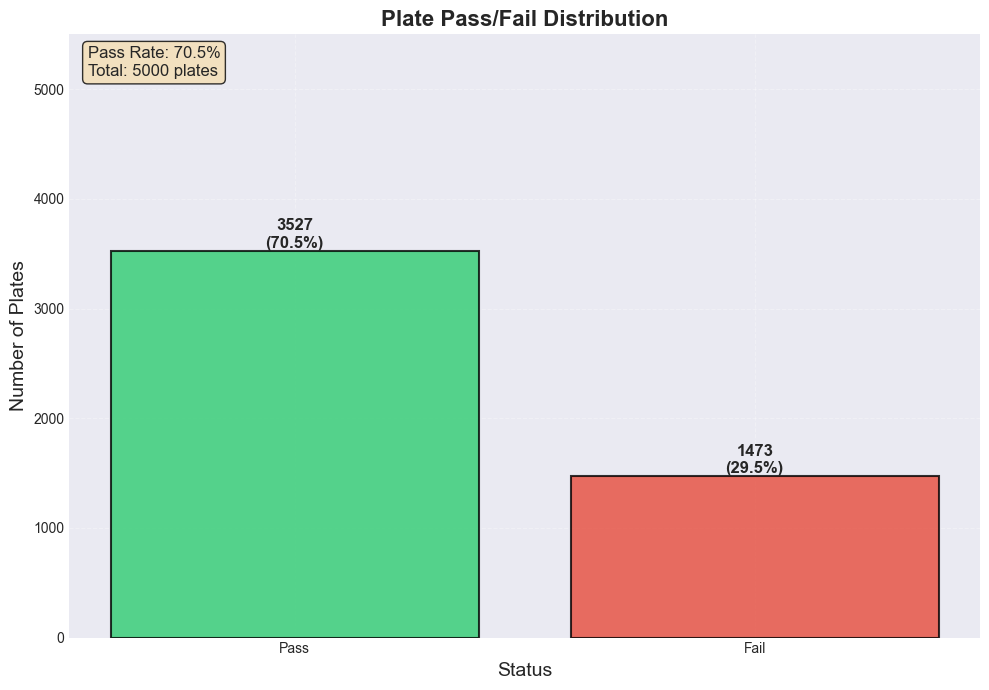

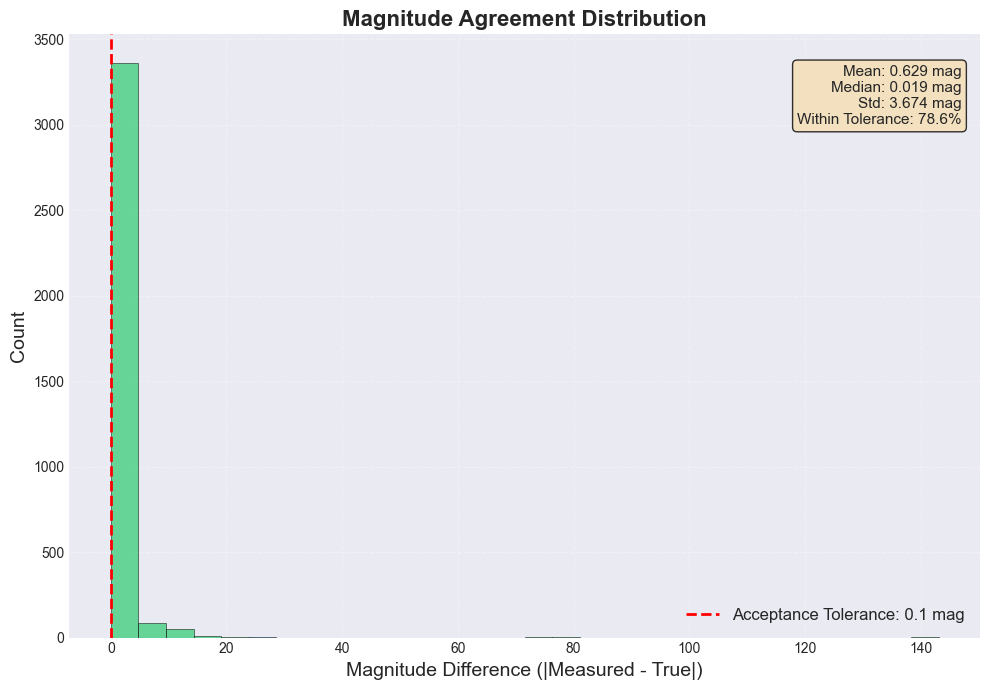

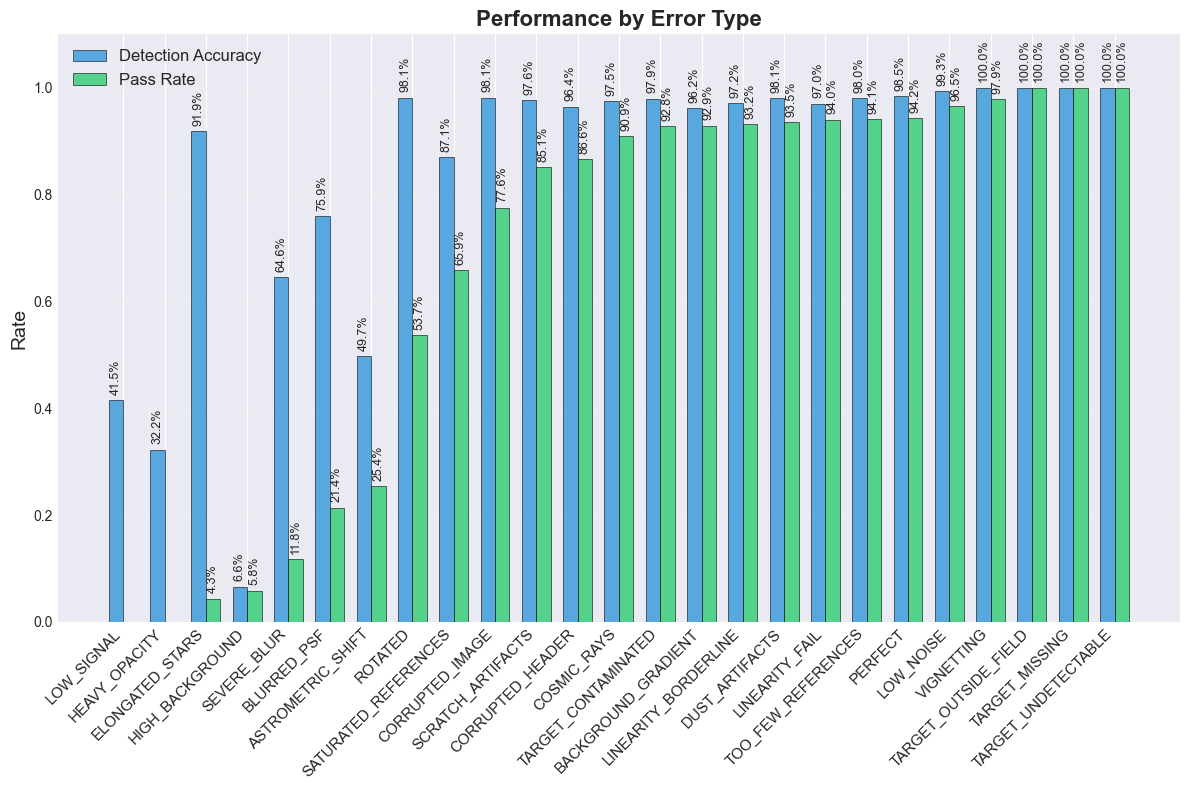

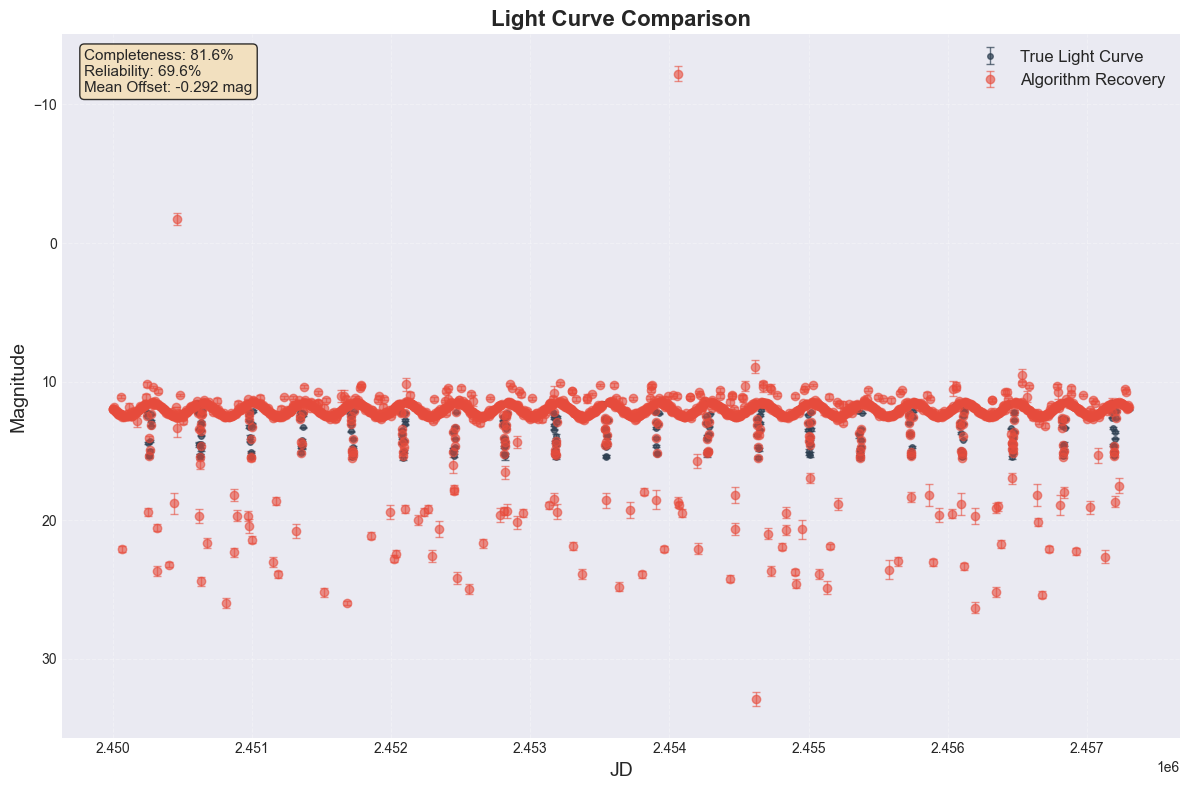

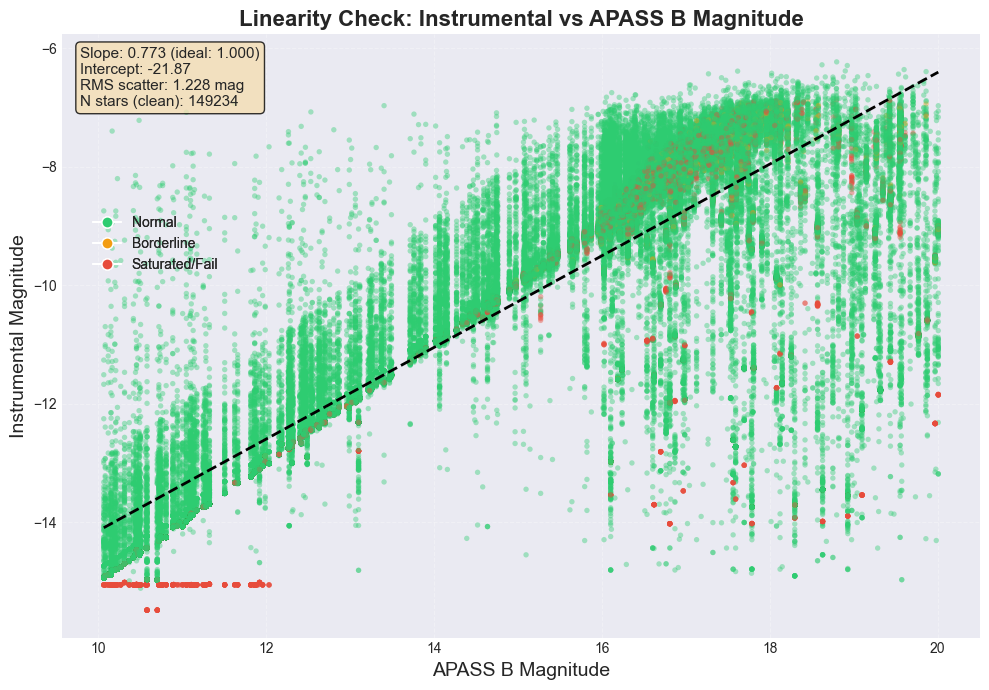

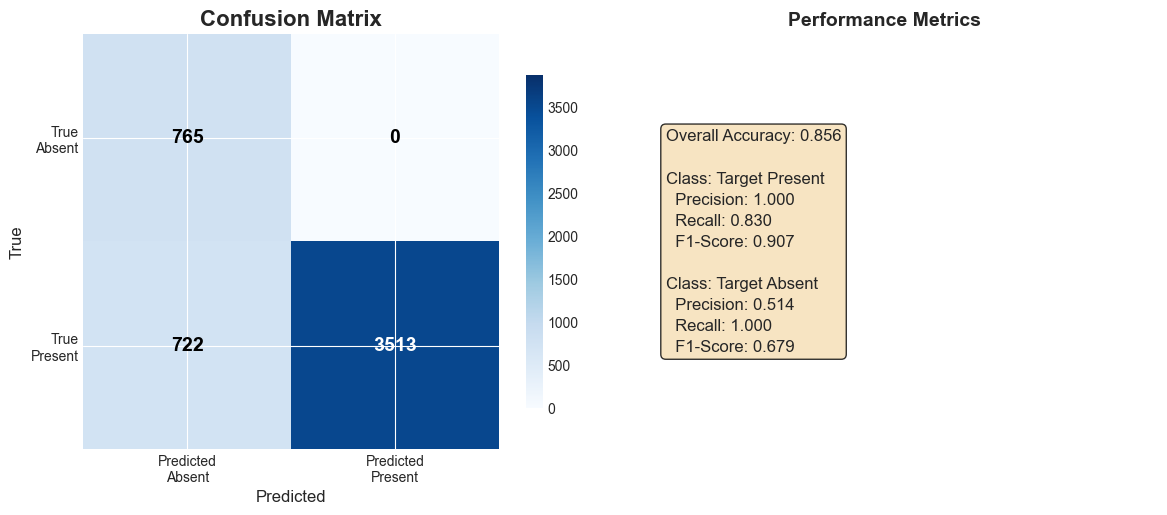

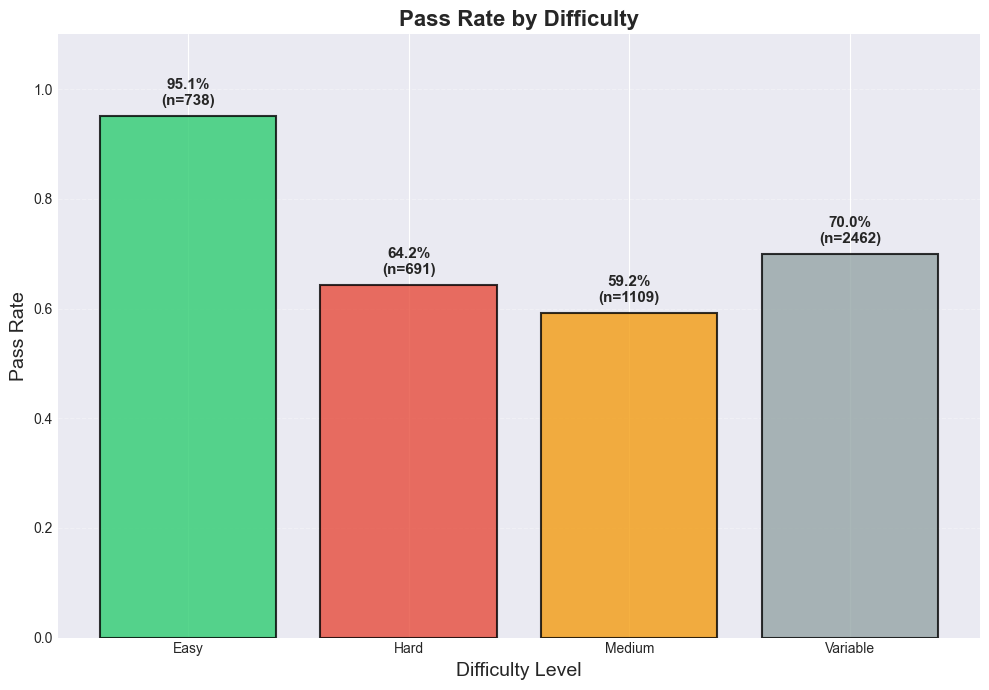

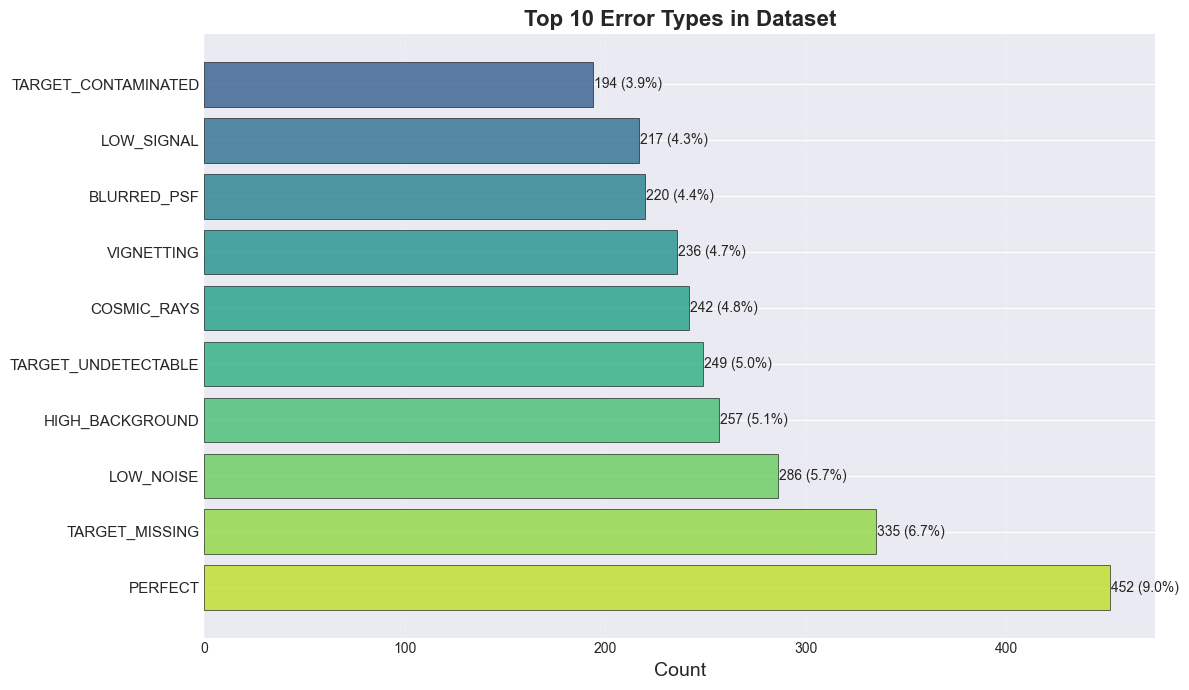

  Saved 8 validation figures to C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests

Generating summary report...
  Saved summary report to C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests\validation_report.txt

FINAL VERDICT
❌ FAIL: Pipeline does not meet minimum performance threshold (≥80%)
   Overall pass rate: 70.5%

Detailed validation results saved to: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests\validation_detailed_results.csv


In [2]:
# NOTE : unit_Test_Generator.ipynb - Cell 2

import os
import pickle
import csv
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import seaborn as sns
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from scipy.spatial import KDTree
from scipy.optimize import curve_fit
from sklearn.metrics import confusion_matrix, classification_report

# ============================================================================
# CONFIGURATION - ADD TOGGLE HERE
# ============================================================================
UNIT_TEST_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests")

# ============================================================================
# INPUT SOURCE TOGGLE - SET THIS TO CONTROL DATA SOURCE
# ============================================================================
USE_SIMULATED_INPUTS = False  # Set to True for testing, False for actual algorithm data

# When USE_SIMULATED_INPUTS = False, the algorithm results are loaded from
# the most recent C:\...\unit_Tests\test_Algorithm_[DATE]_[TIME]\ folder,
# produced by source_Identification_Sorting_And_Photometry_Algorithm.ipynb
#
# NOTE: if the algorithm notebook was run on a SUBSET of plates (e.g. for
# fast iteration), pass rate / completeness / confusion matrix will look
# artificially low, since untouched plates read as "not detected" rather
# than "not attempted." Figures 3 (performance by error type) and 5
# (linearity check) only look at plates the algorithm actually processed,
# so those remain meaningful on a subset run.
# ============================================================================

# Paths to benchmark data
FITS_DIR = UNIT_TEST_DIR / 'cutouts'
ANSWER_KEY_PATH = UNIT_TEST_DIR / 'answer_key.csv'
LIGHT_CURVE_PATH = UNIT_TEST_DIR / 'answer_key_lightcurve.csv'
CATALOG_PATH = UNIT_TEST_DIR / 'synthetic_catalog.csv'

# Path to the actual sorting algorithm output (when USE_SIMULATED_INPUTS = False)
# Auto-discovers the most recently created test_Algorithm_[DATE]_[TIME] folder
def find_latest_algorithm_run(unit_test_dir=UNIT_TEST_DIR, prefix='test_Algorithm_'):
    candidates = [p for p in unit_test_dir.glob(f'{prefix}*') if p.is_dir()]
    if not candidates:
        return None
    return max(candidates, key=lambda p: p.stat().st_mtime)

ALGORITHM_OUTPUT_DIR = find_latest_algorithm_run()
if ALGORITHM_OUTPUT_DIR is not None:
    print(f"Using latest algorithm run: {ALGORITHM_OUTPUT_DIR.name}")
else:
    print("Warning: no test_Algorithm_* run folder found under unit_Tests/")
    ALGORITHM_OUTPUT_DIR = UNIT_TEST_DIR  # falls through to existing 'not found' handling

ALGORITHM_RESULTS_FILE = ALGORITHM_OUTPUT_DIR / 'algorithm_photometry_results.csv'
ALGORITHM_LIGHTCURVE_FILE = ALGORITHM_OUTPUT_DIR / 'algorithm_lightcurve.csv'
ALGORITHM_REF_PHOTOMETRY_FILE = ALGORITHM_OUTPUT_DIR / 'algorithm_reference_photometry.csv'

# Validation thresholds
MAGNITUDE_TOLERANCE = 0.10  # 10% tolerance in magnitude
POSITION_TOLERANCE_PIXELS = 5.0  # 5 pixel matching tolerance
JD_TOLERANCE = 1e-4  # ~8.6 sec; nearest-match tolerance for merging light curves on JD

# ============================================================================
# LOAD BENCHMARK DATA
# ============================================================================

def load_benchmark_data():
    """Load all benchmark data files."""
    print("Loading benchmark data...")
    
    # Load answer key
    answer_key = pd.read_csv(ANSWER_KEY_PATH)
    print(f"  Loaded answer key: {len(answer_key)} plates")
    
    # Load light curve
    light_curve = pd.read_csv(LIGHT_CURVE_PATH)
    print(f"  Loaded light curve: {len(light_curve)} measurements")
    
    # Load catalog
    catalog = pd.read_csv(CATALOG_PATH)
    print(f"  Loaded catalog: {len(catalog)} stars")
    
    return answer_key, light_curve, catalog

# ============================================================================
# SORTING ALGORITHM OUTPUT EXTRACTOR (target detection / photometry)
# ============================================================================

def parse_sorting_algorithm_output():
    """
    Parse the output files from your sorting algorithm.
    Uses the USE_SIMULATED_INPUTS toggle to switch between simulated and real data.
    """
    print("\nParsing sorting algorithm outputs...")
    print(f"  Input mode: {'SIMULATED' if USE_SIMULATED_INPUTS else 'ACTUAL ALGORITHM DATA'}")
    
    if USE_SIMULATED_INPUTS:
        print("  Using simulated algorithm outputs for testing...")
        return parse_simulated_algorithm_output()
    else:
        print("  Using actual sorting algorithm outputs...")
        return parse_actual_algorithm_output()

def parse_simulated_algorithm_output():
    """
    Generate simulated algorithm outputs for testing the validator.
    """
    print("  Generating simulated algorithm results...")
    
    # Load answer key to know what plates exist
    answer_key = pd.read_csv(ANSWER_KEY_PATH)
    
    algorithm_results = pd.DataFrame()
    
    for idx, row in answer_key.iterrows():
        # Simulate detection based on truth
        detected = row['target_present'] and row['target_detectable']
        
        # Add some realistic error scenarios
        if detected and np.random.random() < 0.05:  # 5% false negatives
            detected = False
        
        # Simulate magnitude
        if detected and not pd.isna(row['true_target_magnitude']):
            # Add realistic photometric error
            mag_error = np.random.normal(0, 0.02 + 0.01 * np.random.random())
            mag_meas = row['true_target_magnitude'] + mag_error
            
            # Occasionally add large errors (simulating algorithm failures)
            if np.random.random() < 0.03:  # 3% large errors
                mag_meas += np.random.normal(0, 0.3)
                
            mag_error_est = 0.03 + np.random.uniform(0, 0.05)
        else:
            mag_meas = np.nan
            mag_error_est = np.nan
        
        # Simulate position
        if detected:
            x_pos = row.get('x_position', 100) + np.random.normal(0, 0.5)
            y_pos = row.get('y_position', 100) + np.random.normal(0, 0.5)
        else:
            x_pos = np.nan
            y_pos = np.nan
        
        algorithm_results = pd.concat([
            algorithm_results,
            pd.DataFrame({
                'filename': [row['filename']],
                'target_detected': [detected],
                'target_mag': [mag_meas],
                'target_mag_error': [mag_error_est],
                'target_x': [x_pos],
                'target_y': [y_pos],
                'num_reference_stars': [20 + np.random.randint(0, 30)],
                'zeropoint': [25.0 + np.random.normal(0, 0.05)],
                'rms_scatter': [0.02 + np.random.uniform(0, 0.03)]
            })
        ], ignore_index=True)
    
    print(f"  Generated {len(algorithm_results)} simulated plate results")
    return algorithm_results, None

def parse_actual_algorithm_output():
    """
    Parse the actual sorting algorithm outputs from the notebook.
    """
    print("  Loading actual algorithm outputs...")
    
    # Try to load the main results file
    if ALGORITHM_RESULTS_FILE.exists():
        print(f"  Found algorithm results: {ALGORITHM_RESULTS_FILE}")
        algorithm_results = pd.read_csv(ALGORITHM_RESULTS_FILE)
    else:
        print(f"  Warning: {ALGORITHM_RESULTS_FILE} not found")
        print("  Attempting to locate algorithm output files...")
        algorithm_results = find_algorithm_output_files()
    
    # Try to load the light curve
    light_curve = None
    if ALGORITHM_LIGHTCURVE_FILE.exists():
        print(f"  Found light curve: {ALGORITHM_LIGHTCURVE_FILE}")
        light_curve = pd.read_csv(ALGORITHM_LIGHTCURVE_FILE)
    
    # Try to load plate manifest
    manifest_path = UNIT_TEST_DIR / 'plate_manifest.csv'
    manifest = None
    if manifest_path.exists():
        manifest = pd.read_csv(manifest_path)
    
    return algorithm_results, manifest

def find_algorithm_output_files():
    """
    Search for algorithm output files in various locations.
    """
    # Search in the notebook's output directory
    search_paths = [
        ALGORITHM_OUTPUT_DIR,
        ALGORITHM_OUTPUT_DIR / 'photometry',
        ALGORITHM_OUTPUT_DIR / 'results',
        UNIT_TEST_DIR / 'algorithm_outputs',
        Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data"),
    ]
    
    result_files = []
    for search_path in search_paths:
        if search_path.exists():
            # Look for CSV files that might contain results
            csv_files = list(search_path.glob('*results*.csv')) + \
                       list(search_path.glob('*photometry*.csv')) + \
                       list(search_path.glob('*detections*.csv'))
            if csv_files:
                result_files.extend(csv_files)
                print(f"  Found {len(csv_files)} potential result files in {search_path}")
    
    if result_files:
        # Try to load the most recent file
        latest_file = max(result_files, key=lambda x: x.stat().st_mtime)
        print(f"  Loading latest file: {latest_file}")
        return pd.read_csv(latest_file)
    else:
        print("  No algorithm output files found!")
        print("  Please run the sorting algorithm notebook first:")
        print("  C:\\Users\\dapur\\Downloads\\Other\\Research\\rcb_Star_Dust_Survey\\test_CNN\\notebooks\\02_A_Source_Identification_Sorting_And_Photometry_Algorithm.ipynb")
        print("  Then save the results as:", ALGORITHM_RESULTS_FILE)
        
        # Return empty dataframe with expected columns
        return pd.DataFrame(columns=[
            'filename', 'target_detected', 'target_mag', 'target_x', 'target_y',
            'num_reference_stars', 'reference_star_mags', 'zeropoint', 'rms_scatter'
        ])

def parse_individual_plate_outputs():
    """
    Parse individual plate outputs from the sorting algorithm.
    Customize this based on how your algorithm saves results.
    """
    results = []
    
    # Look for output files in the cutouts directory
    # Assuming algorithm saves files like: utest_00001_PERFECT_results.csv
    result_files = list(FITS_DIR.glob('*_results.csv'))
    
    if result_files:
        print(f"  Found {len(result_files)} individual result files")
        for f in result_files:
            try:
                df = pd.read_csv(f)
                results.append(df)
            except Exception as e:
                print(f"    Warning: Could not parse {f.name}: {e}")
    
    if results:
        return pd.concat(results, ignore_index=True)
    else:
        # Return empty dataframe with expected columns
        print("  No individual results found. Creating empty results structure.")
        return pd.DataFrame(columns=[
            'filename', 'target_detected', 'target_mag', 'target_x', 'target_y',
            'num_reference_stars', 'reference_star_mags', 'zeropoint', 'rms_scatter'
        ])

# ============================================================================
# REFERENCE STAR PHOTOMETRY (linearity / APASS calibration check)
# ============================================================================

def generate_simulated_reference_photometry(answer_key, catalog, n_stars_per_plate=(20, 50)):
    """
    Generate simulated per-plate reference-star instrumental photometry,
    standing in for what the real sorting algorithm would report, so the
    linearity check (instrumental mag vs APASS B mag) can be exercised
    before the real algorithm exists.
    """
    print("  Generating simulated reference star photometry for linearity check...")
    
    ref_catalog = catalog[(catalog['is_target'] == False) & (catalog['is_phantom'] == False)].copy()
    
    if len(ref_catalog) == 0:
        print("  Warning: No non-phantom reference stars found in catalog")
        return pd.DataFrame(columns=['filename', 'star_id', 'error_type', 'instrumental_mag', 'apass_b_mag'])
    
    records = []
    for _, row in answer_key.iterrows():
        error_type = row['error_type']
        zeropoint = row['zeropoint']
        
        n_sample = min(len(ref_catalog), np.random.randint(n_stars_per_plate[0], n_stars_per_plate[1]))
        sample = ref_catalog.sample(n=n_sample)
        
        for _, star in sample.iterrows():
            true_mag = star['mag']
            
            # True instrumental magnitude before any pipeline-specific degradation
            inst_mag = true_mag - zeropoint
            
            # Baseline per-star measurement noise
            inst_mag += np.random.normal(0, 0.01 + 0.02 * np.random.random())
            
            # Error-type specific non-linearity, mirroring the physical effects
            # these error types represent
            if error_type == 'SATURATED_REFERENCES' and true_mag < 12:
                # Saturated pixels: response flattens, no longer tracks brightness
                inst_mag = -15.5 + np.random.normal(0, 0.05)
            elif error_type == 'LINEARITY_FAIL':
                # Systematic compression of the response curve
                inst_mag = (true_mag - zeropoint) * 0.7 + np.random.normal(0, 0.1)
            elif error_type == 'LINEARITY_BORDERLINE':
                if np.random.random() < 0.5:
                    inst_mag += np.random.normal(0, 0.08)
            
            records.append({
                'filename': row['filename'],
                'star_id': star['id'],
                'error_type': error_type,
                'instrumental_mag': inst_mag,
                'apass_b_mag': star['apass_b_mag']
            })
    
    df = pd.DataFrame(records)
    print(f"  Generated {len(df)} simulated reference star measurements")
    return df

def load_actual_reference_photometry(answer_key, catalog):
    """
    Load the real sorting algorithm's per-plate reference star photometry
    and attach truth APASS B magnitudes (by star_id) and error_type (by
    filename) from the synthetic data, if the algorithm output doesn't
    already include them.
    """
    if not ALGORITHM_REF_PHOTOMETRY_FILE.exists():
        print(f"  Warning: {ALGORITHM_REF_PHOTOMETRY_FILE} not found")
        return pd.DataFrame(columns=['filename', 'star_id', 'error_type', 'instrumental_mag', 'apass_b_mag'])
    
    algo_ref = pd.read_csv(ALGORITHM_REF_PHOTOMETRY_FILE)
    
    if 'apass_b_mag' not in algo_ref.columns:
        catalog_lookup = catalog[['id', 'apass_b_mag']].rename(columns={'id': 'star_id'})
        algo_ref = algo_ref.merge(catalog_lookup, on='star_id', how='left')
    
    if 'error_type' not in algo_ref.columns:
        error_lookup = answer_key[['filename', 'error_type']]
        algo_ref = algo_ref.merge(error_lookup, on='filename', how='left')
    
    return algo_ref

def load_reference_photometry(answer_key, catalog):
    """Dispatch reference-star photometry loading based on the input source toggle."""
    print("\nLoading reference star photometry for linearity check...")
    if USE_SIMULATED_INPUTS:
        return generate_simulated_reference_photometry(answer_key, catalog)
    else:
        return load_actual_reference_photometry(answer_key, catalog)

# ============================================================================
# PLATE-LEVEL VALIDATION
# ============================================================================

def validate_plate(truth_row, algorithm_result, tolerance=MAGNITUDE_TOLERANCE):
    """
    Validate a single plate's analysis against the truth.
    
    Returns:
        dict: Validation results including pass/fail status and metrics
    """
    result = {
        'filename': truth_row['filename'],
        'jd': truth_row['jd'],
        'error_type': truth_row['error_type'],
        'target_present_truth': truth_row['target_present'],
        'target_detectable_truth': truth_row['target_detectable'],
        'true_magnitude': truth_row['true_target_magnitude'],
        'expected_magnitude': truth_row['expected_measured_target_magnitude'],
        'expected_photometric_error': truth_row['photometric_error'],
        'algorithm_detected_target': False,
        'algorithm_magnitude': np.nan,
        'algorithm_photometric_error': np.nan,
        'magnitude_agreement': np.nan,
        'magnitude_within_tolerance': False,
        'detection_correct': False,
        'plate_passes': False,
        'rejection_reason': None,
        'comments': ''
    }
    
    # Check if algorithm detected the target
    if algorithm_result is not None and not algorithm_result.empty:
        # Check if algorithm found a target
        if 'target_detected' in algorithm_result.columns:
            result['algorithm_detected_target'] = bool(algorithm_result['target_detected'].iloc[0])
        
        # Get algorithm magnitude if available
        if 'target_mag' in algorithm_result.columns and not pd.isna(algorithm_result['target_mag'].iloc[0]):
            result['algorithm_magnitude'] = algorithm_result['target_mag'].iloc[0]
        
        # Get algorithm photometric error if available
        if 'target_mag_error' in algorithm_result.columns:
            result['algorithm_photometric_error'] = algorithm_result['target_mag_error'].iloc[0]
        elif 'photometric_error' in algorithm_result.columns:
            result['algorithm_photometric_error'] = algorithm_result['photometric_error'].iloc[0]
    
    # Determine if target should be detected (present and detectable)
    target_should_be_detected = (truth_row['target_present'] and truth_row['target_detectable'])
    
    # Check detection correctness
    if target_should_be_detected:
        result['detection_correct'] = result['algorithm_detected_target']
    else:
        # Target should NOT be detected
        result['detection_correct'] = not result['algorithm_detected_target']
    
    # Check magnitude agreement (only if target should be detected and was detected)
    if target_should_be_detected and result['algorithm_detected_target'] and not pd.isna(result['algorithm_magnitude']):
        true_mag = truth_row['true_target_magnitude']
        if not pd.isna(true_mag):
            diff = abs(result['algorithm_magnitude'] - true_mag)
            result['magnitude_agreement'] = diff
            result['magnitude_within_tolerance'] = diff <= tolerance
    
    # Determine plate pass/fail
    # Both conditions must be met:
    # 1. Detection is correct
    # 2. If target is present, magnitude is within tolerance
    if target_should_be_detected:
        result['plate_passes'] = (result['detection_correct'] and result['magnitude_within_tolerance'])
    else:
        result['plate_passes'] = result['detection_correct']
    
    # Determine rejection reason if failed
    if not result['plate_passes']:
        reasons = []
        if not result['detection_correct']:
            if target_should_be_detected:
                reasons.append('Target not detected but should be')
            else:
                reasons.append('Target detected but should not be')
        if target_should_be_detected and not result['magnitude_within_tolerance']:
            reasons.append(f'Magnitude off by {result["magnitude_agreement"]:.3f} mag')
        result['rejection_reason'] = '; '.join(reasons)
    
    return result

# ============================================================================
# LIGHT CURVE VALIDATION
# ============================================================================

def validate_light_curve(algorithm_light_curve, truth_light_curve, jd_tolerance=JD_TOLERANCE):
    """
    Validate the final light curve against the truth.
    
    Matches on JD using nearest-neighbor matching within a tolerance,
    rather than exact equality, since algorithm-computed JDs may differ
    from truth JDs by floating point rounding/serialization noise.
    
    Returns:
        dict: Validation metrics for the light curve
    """
    print("\nValidating light curve...")
    
    # If algorithm light curve is None or empty, create placeholder
    if algorithm_light_curve is None or algorithm_light_curve.empty:
        print("  Warning: No algorithm light curve provided")
        algorithm_light_curve = pd.DataFrame(columns=['jd', 'magnitude', 'magnitude_error'])
    
    # Ensure both have JD columns
    if 'jd' not in algorithm_light_curve.columns:
        print("  Warning: Algorithm light curve missing 'jd' column")
        return {'error': 'Invalid light curve format'}
    
    n_truth = len(truth_light_curve)
    n_algo = len(algorithm_light_curve)
    
    if n_algo == 0:
        print("  Warning: Algorithm light curve is empty")
        return {
            'n_points_algo': 0,
            'n_points_truth': n_truth,
            'n_matched': 0,
            'completeness': 0,
            'reliability': 0,
            'mean_magnitude_diff': np.nan,
            'rms_magnitude_diff': np.nan,
            'mean_magnitude_error': np.nan
        }
    
    # Sort both by jd — required by merge_asof
    truth_sorted = truth_light_curve.sort_values('jd').reset_index(drop=True)
    algo_sorted = algorithm_light_curve.sort_values('jd').reset_index(drop=True)
    
    # Nearest-match on jd within tolerance, instead of exact equality.
    # This tolerates floating point differences from how the real algorithm
    # reads/writes JD (e.g. from FITS headers) vs. how truth stored it.
    merged = pd.merge_asof(
        truth_sorted,
        algo_sorted,
        on='jd',
        direction='nearest',
        tolerance=jd_tolerance,
        suffixes=('_truth', '_algo')
    )
    
    # Rows where no algo match fell within tolerance will have NaN in the
    # algo-side magnitude column — drop those to get only true matches.
    matched = merged.dropna(subset=['magnitude_algo'])
    n_matched = len(matched)
    
    if n_matched == 0:
        print("  Warning: No matching JD points found between truth and algorithm")
        return {
            'n_points_algo': n_algo,
            'n_points_truth': n_truth,
            'n_matched': 0,
            'completeness': 0,
            'reliability': 0,
            'mean_magnitude_diff': np.nan,
            'rms_magnitude_diff': np.nan,
            'mean_magnitude_error': np.nan
        }
    
    # Completeness: fraction of truth points recovered by algorithm
    completeness = n_matched / n_truth if n_truth > 0 else 0
    
    # Reliability: fraction of algorithm points that match truth
    reliability = n_matched / n_algo if n_algo > 0 else 0
    
    # Magnitude differences
    mag_diffs = matched['magnitude_truth'] - matched['magnitude_algo']
    mean_diff = np.mean(mag_diffs)
    rms_diff = np.std(mag_diffs)
    
    # Magnitude error analysis
    if 'magnitude_error_truth' in matched.columns and 'magnitude_error_algo' in matched.columns:
        error_ratio = matched['magnitude_error_algo'] / matched['magnitude_error_truth']
        mean_error_ratio = np.mean(error_ratio)
    else:
        mean_error_ratio = np.nan
    
    metrics = {
        'n_points_truth': n_truth,
        'n_points_algo': n_algo,
        'n_matched': n_matched,
        'completeness': completeness,
        'reliability': reliability,
        'mean_magnitude_diff': mean_diff,
        'rms_magnitude_diff': rms_diff,
        'mean_error_ratio': mean_error_ratio,
        'merged_data': matched
    }
    
    print(f"  Completeness: {completeness:.2%}")
    print(f"  Reliability: {reliability:.2%}")
    print(f"  Mean magnitude difference: {mean_diff:.3f} mag")
    print(f"  RMS magnitude difference: {rms_diff:.3f} mag")
    
    return metrics

# ============================================================================
# ANALYSIS FUNCTIONS
# ============================================================================

def analyze_by_error_type(validation_results):
    """Analyze performance by error type."""
    df = pd.DataFrame(validation_results)
    
    # Group by error type
    summary = df.groupby('error_type').agg({
        'plate_passes': ['count', 'sum', 'mean'],
        'detection_correct': 'mean',
        'magnitude_within_tolerance': 'mean',
        'magnitude_agreement': ['mean', 'std', 'median']
    }).round(4)
    
    # Flatten column names
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    summary = summary.rename(columns={
        'plate_passes_count': 'total_plates',
        'plate_passes_sum': 'plates_passed',
        'plate_passes_mean': 'pass_rate',
        'detection_correct_mean': 'detection_accuracy',
        'magnitude_within_tolerance_mean': 'magnitude_accuracy',
        'magnitude_agreement_mean': 'mean_mag_diff',
        'magnitude_agreement_std': 'std_mag_diff',
        'magnitude_agreement_median': 'median_mag_diff'
    })
    
    return summary

def analyze_by_difficulty(validation_results):
    """Analyze performance by difficulty level."""
    df = pd.DataFrame(validation_results)
    
    # Estimate difficulty based on error type (you can refine this)
    easy_types = ['PERFECT', 'LOW_NOISE']
    medium_types = ['HIGH_BACKGROUND', 'BLURRED_PSF', 'VIGNETTING', 'COSMIC_RAYS', 'DUST_ARTIFACTS']
    hard_types = ['SEVERE_BLUR', 'HEAVY_OPACITY', 'TARGET_CONTAMINATED', 'TARGET_UNDETECTABLE']
    
    def classify_difficulty(error_type):
        if error_type in easy_types:
            return 'Easy'
        elif error_type in medium_types:
            return 'Medium'
        elif error_type in hard_types:
            return 'Hard'
        else:
            return 'Variable'
    
    df['difficulty'] = df['error_type'].apply(classify_difficulty)
    
    summary = df.groupby('difficulty').agg({
        'plate_passes': ['count', 'mean'],
        'detection_correct': 'mean',
        'magnitude_agreement': 'mean'
    }).round(4)
    
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    summary = summary.rename(columns={
        'plate_passes_count': 'total_plates',
        'plate_passes_mean': 'pass_rate',
        'detection_correct_mean': 'detection_accuracy',
        'magnitude_agreement_mean': 'mean_mag_diff'
    })
    
    return summary

def create_confusion_matrix(validation_results):
    """Create confusion matrix for detection."""
    df = pd.DataFrame(validation_results)
    
    # Create binary arrays
    truth = df['target_present_truth'] & df['target_detectable_truth']
    predicted = df['algorithm_detected_target']
    
    # Calculate confusion matrix
    cm = confusion_matrix(truth, predicted)
    
    # Create classification report
    report = classification_report(truth, predicted, 
                                   target_names=['Target Absent', 'Target Present'],
                                   output_dict=True)
    
    return cm, report

# ============================================================================
# PLOTTING FUNCTIONS - IMPROVED VERSION
# ============================================================================

def create_validation_plots(validation_results, light_curve_metrics, truth_light_curve, reference_photometry=None):
    """Create comprehensive validation plots in separate figures."""
    print("\nCreating validation plots...")
    
    df = pd.DataFrame(validation_results)
    
    # Set style for prettier plots
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Figure 1: Pass/Fail Distribution
    fig1, ax1 = plt.subplots(figsize=(10, 7))
    pass_counts = df['plate_passes'].value_counts()
    colors = ['#2ecc71' if k else '#e74c3c' for k in pass_counts.index]
    bars = ax1.bar(['Pass', 'Fail'], [pass_counts.get(True, 0), pass_counts.get(False, 0)], 
                   color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax1.set_title('Plate Pass/Fail Distribution', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Number of Plates', fontsize=14)
    ax1.set_xlabel('Status', fontsize=14)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_ylim(0, len(df) * 1.1)
    
    # Add count labels on bars
    for bar, count in zip(bars, [pass_counts.get(True, 0), pass_counts.get(False, 0)]):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{count}\n({count/len(df)*100:.1f}%)', 
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Add summary text box
    pass_rate = pass_counts.get(True, 0)/len(df)*100
    textstr = f'Pass Rate: {pass_rate:.1f}%\nTotal: {len(df)} plates'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=12,
             verticalalignment='top', bbox=props)
    
    fig1.tight_layout()
    fig1.savefig(UNIT_TEST_DIR / 'fig1_pass_fail_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 2: Magnitude Agreement Histogram
    fig2, ax2 = plt.subplots(figsize=(10, 7))
    valid_mags = df[~df['magnitude_agreement'].isna()]
    if len(valid_mags) > 0:
        n, bins, patches = ax2.hist(valid_mags['magnitude_agreement'], bins=30, 
                                    color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax2.axvline(MAGNITUDE_TOLERANCE, color='red', linestyle='--', linewidth=2,
                   label=f'Acceptance Tolerance: {MAGNITUDE_TOLERANCE} mag')
        ax2.set_xlabel('Magnitude Difference (|Measured - True|)', fontsize=14)
        ax2.set_ylabel('Count', fontsize=14)
        ax2.set_title('Magnitude Agreement Distribution', fontsize=16, fontweight='bold')
        ax2.legend(fontsize=12)
        ax2.grid(True, alpha=0.3, linestyle='--')
        
        # Add statistics
        mean_diff = valid_mags['magnitude_agreement'].mean()
        median_diff = valid_mags['magnitude_agreement'].median()
        std_diff = valid_mags['magnitude_agreement'].std()
        within_tol = (valid_mags['magnitude_agreement'] <= MAGNITUDE_TOLERANCE).sum()
        within_pct = within_tol / len(valid_mags) * 100
        
        stats_text = (f'Mean: {mean_diff:.3f} mag\n'
                     f'Median: {median_diff:.3f} mag\n'
                     f'Std: {std_diff:.3f} mag\n'
                     f'Within Tolerance: {within_pct:.1f}%')
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax2.text(0.98, 0.95, stats_text, transform=ax2.transAxes, 
                fontsize=11, verticalalignment='top', horizontalalignment='right',
                bbox=props)
        
        # Color bars based on tolerance
        for i, (patch, val) in enumerate(zip(patches, valid_mags['magnitude_agreement'].values)):
            if val <= MAGNITUDE_TOLERANCE:
                patch.set_facecolor('#2ecc71')
                patch.set_alpha(0.7)
    
    fig2.tight_layout()
    fig2.savefig(UNIT_TEST_DIR / 'fig2_magnitude_agreement.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 3: Performance by Error Type
    fig3, ax3 = plt.subplots(figsize=(12, 8))
    error_summary = df.groupby('error_type').agg({
        'detection_correct': 'mean',
        'plate_passes': 'mean'
    }).sort_values('plate_passes', ascending=True)
    
    if len(error_summary) > 0:
        x = np.arange(len(error_summary))
        width = 0.35
        
        bars1 = ax3.bar(x - width/2, error_summary['detection_correct'], width, 
                        label='Detection Accuracy', color='#3498db', alpha=0.8,
                        edgecolor='black', linewidth=0.5)
        bars2 = ax3.bar(x + width/2, error_summary['plate_passes'], width, 
                        label='Pass Rate', color='#2ecc71', alpha=0.8,
                        edgecolor='black', linewidth=0.5)
        
        ax3.set_xticks(x)
        ax3.set_xticklabels(error_summary.index, rotation=45, ha='right', fontsize=11)
        ax3.set_ylabel('Rate', fontsize=14)
        ax3.set_title('Performance by Error Type', fontsize=16, fontweight='bold')
        ax3.legend(fontsize=12, loc='best')
        ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax3.set_ylim(0, 1.1)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{height:.1%}', ha='center', va='bottom', fontsize=9, rotation=90)
    
    fig3.tight_layout()
    fig3.savefig(UNIT_TEST_DIR / 'fig3_performance_by_error.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 4: Light Curve Comparison
    fig4, ax4 = plt.subplots(figsize=(12, 8))
    truth_lc = truth_light_curve.sort_values('jd')
    
    # Plot truth with error bars
    ax4.errorbar(truth_lc['jd'], truth_lc['magnitude'], 
                yerr=truth_lc.get('magnitude_error', 0.05),
                fmt='.', color='#2c3e50', alpha=0.7, label='True Light Curve', 
                markersize=8, capsize=3, elinewidth=1)
    
    # Plot algorithm results if available
    if light_curve_metrics and 'merged_data' in light_curve_metrics:
        merged = light_curve_metrics['merged_data'].sort_values('jd')
        if len(merged) > 0:
            ax4.errorbar(merged['jd'], merged['magnitude_algo'],
                        yerr=merged.get('magnitude_error_algo', 0.05),
                        fmt='o', color='#e74c3c', alpha=0.6, 
                        label='Algorithm Recovery', markersize=6,
                        capsize=3, elinewidth=1)
    
    ax4.set_xlabel('JD', fontsize=14)
    ax4.set_ylabel('Magnitude', fontsize=14)
    ax4.set_title('Light Curve Comparison', fontsize=16, fontweight='bold')
    ax4.legend(fontsize=12, loc='best')
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.invert_yaxis()
    
    # Add metrics if available
    if light_curve_metrics and 'error' not in light_curve_metrics:
        metrics_text = (f'Completeness: {light_curve_metrics.get("completeness", 0):.1%}\n'
                       f'Reliability: {light_curve_metrics.get("reliability", 0):.1%}')
        if 'mean_magnitude_diff' in light_curve_metrics:
            metrics_text += f'\nMean Offset: {light_curve_metrics["mean_magnitude_diff"]:.3f} mag'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax4.text(0.02, 0.98, metrics_text, transform=ax4.transAxes, 
                fontsize=11, verticalalignment='top', bbox=props)
    
    fig4.tight_layout()
    fig4.savefig(UNIT_TEST_DIR / 'fig4_light_curve_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 5: Linearity Check - Instrumental Magnitude vs APASS B Magnitude
    fig5, ax5 = plt.subplots(figsize=(10, 7))
    if reference_photometry is not None and len(reference_photometry) > 0:
        ref_df = reference_photometry.dropna(subset=['instrumental_mag', 'apass_b_mag'])
        
        bad_types = {'SATURATED_REFERENCES', 'LINEARITY_FAIL'}
        borderline_types = {'LINEARITY_BORDERLINE'}
        
        if 'error_type' in ref_df.columns:
            def point_color(et):
                if et in bad_types:
                    return '#e74c3c'
                elif et in borderline_types:
                    return '#f39c12'
                else:
                    return '#2ecc71'
            colors = ref_df['error_type'].apply(point_color)
        else:
            colors = '#2ecc71'
        
        ax5.scatter(ref_df['apass_b_mag'], ref_df['instrumental_mag'],
                   alpha=0.4, c=colors, s=15, edgecolor='none')
        
        # Fit linear relation using only well-behaved plates, to show the
        # expected clean response
        if 'error_type' in ref_df.columns:
            clean = ref_df[~ref_df['error_type'].isin(bad_types | borderline_types)]
        else:
            clean = ref_df
        
        if len(clean) > 2:
            slope, intercept = np.polyfit(clean['apass_b_mag'], clean['instrumental_mag'], 1)
            x_fit = np.linspace(ref_df['apass_b_mag'].min(), ref_df['apass_b_mag'].max(), 100)
            ax5.plot(x_fit, slope * x_fit + intercept, color='black', linestyle='--',
                    linewidth=2, label=f'Fit: slope={slope:.3f}, intercept={intercept:.2f}')
            
            residuals = clean['instrumental_mag'] - (slope * clean['apass_b_mag'] + intercept)
            rms = np.std(residuals)
            
            stats_text = (f'Slope: {slope:.3f} (ideal: 1.000)\n'
                         f'Intercept: {intercept:.2f}\n'
                         f'RMS scatter: {rms:.3f} mag\n'
                         f'N stars (clean): {len(clean)}')
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            ax5.text(0.02, 0.98, stats_text, transform=ax5.transAxes,
                    fontsize=11, verticalalignment='top', bbox=props)
            ax5.legend(fontsize=10, loc='lower right')
        
        # Legend for point colors
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=8, label='Normal'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12', markersize=8, label='Borderline'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Saturated/Fail'),
        ]
        leg2 = ax5.legend(handles=legend_elements, fontsize=10, loc='upper left', bbox_to_anchor=(0.02, 0.72))
        ax5.add_artist(leg2)
        
        ax5.set_xlabel('APASS B Magnitude', fontsize=14)
        ax5.set_ylabel('Instrumental Magnitude', fontsize=14)
        ax5.set_title('Linearity Check: Instrumental vs APASS B Magnitude', fontsize=16, fontweight='bold')
        ax5.grid(True, alpha=0.3, linestyle='--')
    else:
        ax5.text(0.5, 0.5, 'No reference photometry available', ha='center', va='center', fontsize=14)
        ax5.set_title('Linearity Check: Instrumental vs APASS B Magnitude', fontsize=16, fontweight='bold')
    
    fig5.tight_layout()
    fig5.savefig(UNIT_TEST_DIR / 'fig5_linearity_check.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 6: Confusion Matrix
    fig6, (ax6, ax6b) = plt.subplots(1, 2, figsize=(12, 5))
    cm, report = create_confusion_matrix(validation_results)
    
    # Heatmap
    im = ax6.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=cm.max()*1.1)
    ax6.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
    ax6.set_xticks([0, 1])
    ax6.set_yticks([0, 1])
    ax6.set_xticklabels(['Predicted\nAbsent', 'Predicted\nPresent'])
    ax6.set_yticklabels(['True\nAbsent', 'True\nPresent'])
    ax6.set_xlabel('Predicted', fontsize=12)
    ax6.set_ylabel('True', fontsize=12)
    plt.colorbar(im, ax=ax6, shrink=0.8)
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            ax6.text(j, i, str(cm[i, j]), ha='center', va='center', 
                    color='white' if cm[i, j] > cm.max()/2 else 'black',
                    fontsize=14, fontweight='bold')
    
    # Metrics panel
    if 'accuracy' in report:
        class_labels = [k for k in report.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']]
        present_class = [cls for cls in class_labels if 'Present' in cls]
        
        metrics_text = f"Overall Accuracy: {report['accuracy']:.3f}\n\n"
        if present_class:
            p = report[present_class[0]]
            metrics_text += f"Class: {present_class[0]}\n"
            metrics_text += f"  Precision: {p['precision']:.3f}\n"
            metrics_text += f"  Recall: {p['recall']:.3f}\n"
            metrics_text += f"  F1-Score: {p['f1-score']:.3f}\n\n"
        if 'absent' in class_labels[0].lower():
            p = report[class_labels[0]]
            metrics_text += f"Class: {class_labels[0]}\n"
            metrics_text += f"  Precision: {p['precision']:.3f}\n"
            metrics_text += f"  Recall: {p['recall']:.3f}\n"
            metrics_text += f"  F1-Score: {p['f1-score']:.3f}"
        
        ax6b.text(0.1, 0.5, metrics_text, transform=ax6b.transAxes, 
                 fontsize=12, va='center', linespacing=1.5,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        ax6b.set_xticks([])
        ax6b.set_yticks([])
        ax6b.set_frame_on(False)
        ax6b.set_title('Performance Metrics', fontsize=14, fontweight='bold')
    
    fig6.tight_layout()
    fig6.savefig(UNIT_TEST_DIR / 'fig6_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 7: Pass Rate by Difficulty
    fig7, ax7 = plt.subplots(figsize=(10, 7))
    difficulty_summary = analyze_by_difficulty(validation_results)
    if len(difficulty_summary) > 0:
        colors = {'Easy': '#2ecc71', 'Medium': '#f39c12', 'Hard': '#e74c3c', 
                 'Variable': '#95a5a6'}
        bar_colors = [colors.get(d, '#95a5a6') for d in difficulty_summary.index]
        bars = ax7.bar(difficulty_summary.index, difficulty_summary['pass_rate'], 
                       color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
        ax7.set_ylabel('Pass Rate', fontsize=14)
        ax7.set_xlabel('Difficulty Level', fontsize=14)
        ax7.set_title('Pass Rate by Difficulty', fontsize=16, fontweight='bold')
        ax7.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax7.set_ylim(0, 1.1)
        
        # Add value labels and counts on bars
        for i, (idx, row) in enumerate(difficulty_summary.iterrows()):
            height = row['pass_rate']
            ax7.text(i, height + 0.02, f'{height:.1%}\n(n={int(row["total_plates"])})', 
                    ha='center', fontsize=11, fontweight='bold')
    
    fig7.tight_layout()
    fig7.savefig(UNIT_TEST_DIR / 'fig7_difficulty_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 8: Top Error Types Distribution
    fig8, ax8 = plt.subplots(figsize=(12, 7))
    error_counts = df['error_type'].value_counts()
    top_errors = error_counts.head(10)
    
    if len(top_errors) > 0:
        # Horizontal bar chart with gradient colors
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_errors)))[::-1]
        bars = ax8.barh(range(len(top_errors)), top_errors.values, 
                       color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        ax8.set_yticks(range(len(top_errors)))
        ax8.set_yticklabels(top_errors.index, fontsize=11)
        ax8.set_xlabel('Count', fontsize=14)
        ax8.set_title('Top 10 Error Types in Dataset', fontsize=16, fontweight='bold')
        ax8.grid(True, alpha=0.3, linestyle='--', axis='x')
        
        # Add value labels
        total = len(df)
        for i, (bar, count) in enumerate(zip(bars, top_errors.values)):
            ax8.text(count + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{count} ({count/total:.1%})',
                    va='center', fontsize=10)
    
    fig8.tight_layout()
    fig8.savefig(UNIT_TEST_DIR / 'fig8_error_types.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  Saved 8 validation figures to {UNIT_TEST_DIR}")
    
    return None  # Return None as we're showing separate figures

# ============================================================================
# GENERATE SUMMARY REPORT
# ============================================================================

def generate_summary_report(validation_results, light_curve_metrics, summary_stats, reference_photometry=None):
    """Generate a comprehensive summary report."""
    print("\nGenerating summary report...")
    
    df = pd.DataFrame(validation_results)
    
    # Create report
    report_lines = []
    report_lines.append("=" * 80)
    report_lines.append("RCB PHOTOMETRIC PIPELINE UNIT TEST SUMMARY")
    report_lines.append("=" * 80)
    report_lines.append(f"Test Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report_lines.append(f"Input Source: {'SIMULATED' if USE_SIMULATED_INPUTS else 'ACTUAL ALGORITHM'}")
    report_lines.append("")
    
    # Overall statistics
    report_lines.append("OVERALL STATISTICS")
    report_lines.append("-" * 40)
    total_plates = len(df)
    passed_plates = df['plate_passes'].sum()
    pass_rate = passed_plates / total_plates * 100
    
    report_lines.append(f"Total plates processed: {total_plates}")
    report_lines.append(f"Plates passing: {passed_plates}")
    report_lines.append(f"Pass rate: {pass_rate:.1f}%")
    report_lines.append("")
    
    # Detection statistics
    detection_correct = df['detection_correct'].sum()
    detection_rate = detection_correct / total_plates * 100
    report_lines.append(f"Detection correctness: {detection_correct}/{total_plates} ({detection_rate:.1f}%)")
    
    # Magnitude statistics
    valid_mags = df[~df['magnitude_agreement'].isna()]
    if len(valid_mags) > 0:
        mean_diff = valid_mags['magnitude_agreement'].mean()
        std_diff = valid_mags['magnitude_agreement'].std()
        mag_accuracy = valid_mags['magnitude_within_tolerance'].sum() / len(valid_mags) * 100
        report_lines.append(f"Magnitude accuracy (within {MAGNITUDE_TOLERANCE} mag): {mag_accuracy:.1f}%")
        report_lines.append(f"Mean magnitude difference: {mean_diff:.3f} ± {std_diff:.3f} mag")
    report_lines.append("")
    
    # Light curve statistics
    if light_curve_metrics and 'error' not in light_curve_metrics:
        report_lines.append("LIGHT CURVE STATISTICS")
        report_lines.append("-" * 40)
        report_lines.append(f"Truth points: {light_curve_metrics.get('n_points_truth', 0)}")
        report_lines.append(f"Algorithm points: {light_curve_metrics.get('n_points_algo', 0)}")
        report_lines.append(f"Matched points: {light_curve_metrics.get('n_matched', 0)}")
        report_lines.append(f"Completeness: {light_curve_metrics.get('completeness', 0):.2%}")
        report_lines.append(f"Reliability: {light_curve_metrics.get('reliability', 0):.2%}")
        if 'mean_magnitude_diff' in light_curve_metrics:
            report_lines.append(f"Mean magnitude offset: {light_curve_metrics['mean_magnitude_diff']:.3f} mag")
            report_lines.append(f"RMS magnitude scatter: {light_curve_metrics['rms_magnitude_diff']:.3f} mag")
    report_lines.append("")
    
    # Linearity check statistics
    if reference_photometry is not None and len(reference_photometry) > 0:
        report_lines.append("LINEARITY CHECK (Instrumental vs APASS B Magnitude)")
        report_lines.append("-" * 40)
        ref_df = reference_photometry.dropna(subset=['instrumental_mag', 'apass_b_mag'])
        bad_types = {'SATURATED_REFERENCES', 'LINEARITY_FAIL'}
        borderline_types = {'LINEARITY_BORDERLINE'}
        if 'error_type' in ref_df.columns:
            clean = ref_df[~ref_df['error_type'].isin(bad_types | borderline_types)]
        else:
            clean = ref_df
        if len(clean) > 2:
            slope, intercept = np.polyfit(clean['apass_b_mag'], clean['instrumental_mag'], 1)
            residuals = clean['instrumental_mag'] - (slope * clean['apass_b_mag'] + intercept)
            rms = np.std(residuals)
            report_lines.append(f"Stars used (clean plates): {len(clean)}")
            report_lines.append(f"Fitted slope: {slope:.4f} (ideal: 1.000)")
            report_lines.append(f"Fitted intercept: {intercept:.3f}")
            report_lines.append(f"RMS scatter: {rms:.3f} mag")
        report_lines.append(f"Total reference measurements: {len(ref_df)}")
        report_lines.append("")
    
    # Performance by error type
    report_lines.append("PERFORMANCE BY ERROR TYPE")
    report_lines.append("-" * 40)
    error_summary = analyze_by_error_type(validation_results)
    report_lines.append(error_summary.to_string())
    report_lines.append("")
    
    # Confusion matrix
    report_lines.append("CONFUSION MATRIX")
    report_lines.append("-" * 40)
    cm, _ = create_confusion_matrix(validation_results)
    report_lines.append(f"True Positive: {cm[1,1]}")
    report_lines.append(f"True Negative: {cm[0,0]}")
    report_lines.append(f"False Positive: {cm[0,1]}")
    report_lines.append(f"False Negative: {cm[1,0]}")
    report_lines.append("")
    
    # Top failures
    report_lines.append("TOP FAILURE REASONS")
    report_lines.append("-" * 40)
    failed = df[~df['plate_passes']]
    if len(failed) > 0:
        # Count rejection reasons
        reasons = failed['rejection_reason'].value_counts().head(10)
        for reason, count in reasons.items():
            report_lines.append(f"  {reason}: {count} plates ({count/len(failed)*100:.1f}%)")
    else:
        report_lines.append("  No failures!")
    report_lines.append("")
    
    report_lines.append("=" * 80)
    report_lines.append("END OF REPORT")
    report_lines.append("=" * 80)
    
    # Save report
    report_text = "\n".join(report_lines)
    report_path = UNIT_TEST_DIR / 'validation_report.txt'
    with open(report_path, 'w') as f:
        f.write(report_text)
    
    print(f"  Saved summary report to {report_path}")
    
    return report_text

# ============================================================================
# MAIN VALIDATION FUNCTION
# ============================================================================

def run_validation():
    """Main validation function."""
    global USE_SIMULATED_INPUTS  # Move global declaration to the top of the function
    
    print("=" * 80)
    print("RCB PHOTOMETRIC PIPELINE UNIT TEST VALIDATOR")
    print("=" * 80)
    print(f"\nInput Mode: {'SIMULATED' if USE_SIMULATED_INPUTS else 'ACTUAL ALGORITHM DATA'}")
    print(f"Data Directory: {UNIT_TEST_DIR}")
    print("=" * 80)
    
    # Load benchmark data
    answer_key, truth_light_curve, catalog = load_benchmark_data()
    
    # Parse algorithm output (uses toggle internally)
    algorithm_results, manifest = parse_sorting_algorithm_output()
    
    # If no algorithm results were found and using real data, show helpful message
    if not USE_SIMULATED_INPUTS and (algorithm_results is None or algorithm_results.empty):
        print("\n❌ ERROR: No algorithm results found!")
        print("\nPlease ensure you have:")
        print("1. Run the sorting algorithm notebook:")
        print("   C:\\Users\\dapur\\Downloads\\Other\\Research\\rcb_Star_Dust_Survey\\test_CNN\\notebooks\\source_Identification_Sorting_And_Photometry_Algorithm.ipynb")
        print("2. Saved the results to:", ALGORITHM_RESULTS_FILE)
        print("3. Or set USE_SIMULATED_INPUTS = True to test with simulated data")
        print("\nSwitching to simulated data for testing...")
        # Fallback to simulated for testing
        USE_SIMULATED_INPUTS = True
        algorithm_results, manifest = parse_sorting_algorithm_output()
    
    # Validate each plate
    print("\nValidating individual plates...")
    validation_results = []
    
    for idx, truth_row in answer_key.iterrows():
        # Find algorithm result for this plate
        algo_row = algorithm_results[algorithm_results['filename'] == truth_row['filename']]
        if len(algo_row) == 0:
            algo_row = pd.DataFrame()  # Empty if not found
        
        # Validate plate
        result = validate_plate(truth_row, algo_row)
        validation_results.append(result)
    
    # Convert to DataFrame for analysis
    validation_df = pd.DataFrame(validation_results)
    
    # Validate light curve (if available)
    if not USE_SIMULATED_INPUTS and ALGORITHM_LIGHTCURVE_FILE.exists():
        algorithm_light_curve = pd.read_csv(ALGORITHM_LIGHTCURVE_FILE)
        light_curve_metrics = validate_light_curve(algorithm_light_curve, truth_light_curve)
    else:
        # Use simulated light curve or skip
        print("\nGenerating simulated light curve for testing...")
        # Create simulated light curve from validation results
        algorithm_light_curve = pd.DataFrame()
        for result in validation_results:
            if result['algorithm_detected_target'] and not pd.isna(result['algorithm_magnitude']):
                jd = result['jd']
                algorithm_light_curve = pd.concat([
                    algorithm_light_curve,
                    pd.DataFrame({
                        'jd': [jd],
                        'magnitude': [result['algorithm_magnitude']],
                        'magnitude_error': [result.get('algorithm_photometric_error', 0.05)]
                    })
                ], ignore_index=True)
        light_curve_metrics = validate_light_curve(algorithm_light_curve, truth_light_curve)
    
    # Load reference star photometry (simulated or actual) for the linearity check
    reference_photometry = load_reference_photometry(answer_key, catalog)
    
    # Calculate summary statistics
    summary_stats = {
        'total_plates': len(validation_df),
        'passed_plates': validation_df['plate_passes'].sum(),
        'pass_rate': validation_df['plate_passes'].mean(),
        'detection_correct': validation_df['detection_correct'].mean(),
        'magnitude_accuracy': validation_df['magnitude_within_tolerance'].mean() if 'magnitude_within_tolerance' in validation_df.columns else np.nan
    }
    
    # Print summary
    print("\n" + "=" * 60)
    print("VALIDATION SUMMARY")
    print("=" * 60)
    print(f"Input Source: {'SIMULATED' if USE_SIMULATED_INPUTS else 'ACTUAL ALGORITHM'}")
    print(f"Total plates processed: {summary_stats['total_plates']}")
    print(f"Plates passing: {summary_stats['passed_plates']}")
    print(f"Pass rate: {summary_stats['pass_rate']*100:.1f}%")
    print(f"Detection correctness: {summary_stats['detection_correct']*100:.1f}%")
    if not pd.isna(summary_stats['magnitude_accuracy']):
        print(f"Magnitude accuracy: {summary_stats['magnitude_accuracy']*100:.1f}%")
    print("=" * 60)
    
    # Create plots
    fig = create_validation_plots(validation_results, light_curve_metrics, truth_light_curve, reference_photometry)
    
    # Generate summary report
    report = generate_summary_report(validation_results, light_curve_metrics, summary_stats, reference_photometry)
    
    # Print final verdict
    print("\n" + "=" * 60)
    print("FINAL VERDICT")
    print("=" * 60)
    if summary_stats['pass_rate'] >= 0.8:
        print("✅ PASS: Pipeline meets minimum performance threshold (≥80%)")
        print(f"   Overall pass rate: {summary_stats['pass_rate']*100:.1f}%")
    else:
        print("❌ FAIL: Pipeline does not meet minimum performance threshold (≥80%)")
        print(f"   Overall pass rate: {summary_stats['pass_rate']*100:.1f}%")
    
    # Save results
    validation_df.to_csv(UNIT_TEST_DIR / 'validation_detailed_results.csv', index=False)
    print(f"\nDetailed validation results saved to: {UNIT_TEST_DIR / 'validation_detailed_results.csv'}")
    
    return validation_df, light_curve_metrics, summary_stats

# ============================================================================
# RUN VALIDATION
# ============================================================================

if __name__ == "__main__":
    validation_results, light_curve_metrics, summary_stats = run_validation()